## SETUP CELL

In [309]:
# ============================================================
# SETUP CELL: imports, metadata, split functions, val split
# Run this cell FIRST after restarting kernel
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np
import os, gc, json, random, platform
import datetime as dt
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from functools import lru_cache, partial
from fastai.vision.all import *
from fastai.vision.all import Resize, ResizeMethod, PadMode, aug_transforms
from fastai.vision.all import (
    ResizeMethod, PadMode,
    FlipItem,
    Brightness, Contrast
)
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
from torch.amp import autocast

MANIFEST = Path("/margrethe/images/manifests/manifest_all_fresh2.csv")
MODEL_ROOT = Path("/margrethe/code/models")
MODEL_DIR = "ViT_PROTOCOLS_reporting"
VALID_PCT = 0.2
SEED = 42
TARGET_COL = "score01"

KNOWN_SOURCES = ("custom", "youtube", "EDAMB")

# ============================================================
# METADATA EXTRACTION
# ============================================================
EDAMB_CAMERA_MAP = {
    "Canon-EOS50D": "Canon-EOS50D",
    "Canon-SC200IS": "Canon-SC200IS",
    "Canon-PowerShot": "Canon-SC200IS",
    "Kodak-DX6490": "Kodak-DX6490",
    "Kodak-EasyShare": "Kodak-DX6490",
}

def _best_path_for_metadata(row):
    for col in ["aligned_path", "minimal_aligned_path", "raw_path", "key"]:
        if col in row and pd.notna(row[col]):
            s = str(row[col]).strip()
            if s:
                return s
    return ""

def _extract_edamb_location(path_str):
    if not path_str:
        return np.nan
    s = str(path_str)
    m = re.search(r"/EDAMB/(Essen|HDA)/", s)
    if m:
        return m.group(1)
    if "from-Essen" in s or "/Essen/" in s:
        return "Essen"
    if "from-HDA" in s or "from-Darmstadt" in s or "/HDA/" in s:
        return "HDA"
    return np.nan

def _extract_edamb_camera(path_str):
    if not path_str:
        return np.nan
    s = str(path_str)
    for raw_name, normalized in EDAMB_CAMERA_MAP.items():
        if raw_name in s:
            return normalized
    if "EOS50D" in s:
        return "Canon-EOS50D"
    if "SC200IS" in s or "PowerShot" in s:
        return "Canon-SC200IS"
    if "DX6490" in s or "EasyShare" in s:
        return "Kodak-DX6490"
    return np.nan

def _extract_edamb_subject_id(path_str):
    if not path_str:
        return np.nan
    p = Path(str(path_str))
    if not p.parent or not p.parent.name:
        return np.nan
    subj = p.parent.name.strip()
    if subj in {"EDAMB", "Essen", "HDA"}:
        return np.nan
    if ("Canon" in subj) or ("Kodak" in subj):
        return np.nan
    return subj if subj else np.nan

def _extract_custom_subject_id(row):
    if str(row.get("source", "")) != "custom":
        return np.nan

    g = row.get("group", np.nan)
    if pd.notna(g):
        g = str(g).strip()
        if g and g.lower() != "unknown":
            return g

    for col in ["key", "aligned_path", "minimal_aligned_path", "raw_path"]:
        if col in row and pd.notna(row[col]):
            s = str(row[col])
            m = re.search(r"(?:^|/)custom/([^/]+)/", s)
            if m:
                return m.group(1)
    return np.nan

def _extract_youtube_video_id(row):
    if str(row.get("source", "")) != "youtube":
        return np.nan

    # Preferred: group, since your merged Sharp/MotionBlur folders appear to use
    # a shared identity at video/group level.
    g = row.get("group", np.nan)
    if pd.notna(g):
        g = str(g).strip()
        if g and g.lower() != "unknown":
            return g

    # Fallback: try parsing from path
    for col in ["key", "aligned_path", "minimal_aligned_path", "raw_path"]:
        if col in row and pd.notna(row[col]):
            s = str(row[col])
            m = re.search(r"(?:^|/)youtube/([^/]+)/", s)
            if m:
                return m.group(1)
    return np.nan

def add_metadata(df):
    d = df.copy()
    path_series = d.apply(_best_path_for_metadata, axis=1)

    is_edamb = d["source"].astype(str).eq("EDAMB")
    is_custom = d["source"].astype(str).eq("custom")
    is_youtube = d["source"].astype(str).eq("youtube")

    d["edamb_location"] = np.where(
        is_edamb,
        path_series.map(_extract_edamb_location),
        np.nan
    )
    d["edamb_camera"] = np.where(
        is_edamb,
        path_series.map(_extract_edamb_camera),
        np.nan
    )
    d["edamb_subject_id"] = np.where(
        is_edamb,
        path_series.map(_extract_edamb_subject_id),
        np.nan
    )

    d["custom_subject_id"] = d.apply(_extract_custom_subject_id, axis=1)
    d["youtube_video_id"] = d.apply(_extract_youtube_video_id, axis=1)

    d["group"] = d["group"].fillna("unknown").astype(str)

    # This is the grouping unit used for train/validation splitting.
    # - EDAMB -> subject-safe
    # - custom -> subject/group-safe
    # - youtube -> video/group-safe
    d["split_unit"] = np.select(
        [
            is_edamb & d["edamb_subject_id"].notna(),
            is_custom & d["custom_subject_id"].notna(),
            is_youtube & d["youtube_video_id"].notna(),
        ],
        [
            "EDAMB_SUBJECT::" + d["edamb_subject_id"].astype(str),
            "CUSTOM_SUBJECT::" + d["custom_subject_id"].astype(str),
            "YOUTUBE_VIDEO::" + d["youtube_video_id"].astype(str),
        ],
        default=d["source"].astype(str) + "::GROUP::" + d["group"].astype(str)
    )

    return d

# ============================================================
# SPLIT REPORTING / SANITY-CHECK HELPERS
# ============================================================
def _counts_or_empty(df, col):
    if col not in df.columns or len(df) == 0:
        return {}
    return df[col].fillna("<NA>").astype(str).value_counts(dropna=False).to_dict()

def _unique_non_null(df, col):
    if col not in df.columns or len(df) == 0:
        return set()
    return set(df[col].dropna().astype(str).tolist())

def _print_source_breakdown(df, title, split_col="split_unit"):
    print(f"\n--- {title} ---")
    if len(df) == 0:
        print("Rows: 0")
        return

    print("Rows:", len(df))
    print("Source counts:", _counts_or_empty(df, "source"))

    if split_col in df.columns:
        by_source_units = (
            df.groupby("source")[split_col]
              .nunique(dropna=True)
              .sort_index()
              .to_dict()
        )
        print(f"Unique {split_col} per source:", by_source_units)

    if "group" in df.columns:
        print(
            "Unique groups per source:",
            df.groupby("source")["group"].nunique(dropna=True).sort_index().to_dict()
        )

    if "edamb_subject_id" in df.columns:
        ed = df[df["source"] == "EDAMB"].copy()
        if len(ed):
            print("EDAMB unique subjects:", ed["edamb_subject_id"].dropna().astype(str).nunique())
            print("EDAMB locations:", _counts_or_empty(ed, "edamb_location"))
            print("EDAMB cameras:", _counts_or_empty(ed, "edamb_camera"))

    if "custom_subject_id" in df.columns:
        cu = df[df["source"] == "custom"].copy()
        if len(cu):
            print("Custom unique subjects:", cu["custom_subject_id"].dropna().astype(str).nunique())

    if "youtube_video_id" in df.columns:
        yt = df[df["source"] == "youtube"].copy()
        if len(yt):
            print("YouTube unique video IDs:", yt["youtube_video_id"].dropna().astype(str).nunique())

def print_split_summary(trainval_df, test_df, split_info=None, split_col="split_unit"):
    print("\n============================================================")
    print("SPLIT SUMMARY")
    print("============================================================")

    if split_info is not None:
        for k in [
            "protocol_name",
            "protocol_key",
            "split_mode",
            "held_out_source",
            "train_sources",
            "test_sources",
            "n_trainval_total",
            "n_test_total",
        ]:
            if k in split_info:
                print(f"{k}: {split_info[k]}")

    _print_source_breakdown(trainval_df, "TRAIN/VALIDATION POOL", split_col=split_col)
    _print_source_breakdown(test_df, "TEST POOL", split_col=split_col)

    print("\n--- Overlap checks (trainval vs test) ---")
    for col in ["split_unit", "edamb_subject_id", "custom_subject_id", "youtube_video_id", "group"]:
        if col in trainval_df.columns and col in test_df.columns:
            overlap = _unique_non_null(trainval_df, col) & _unique_non_null(test_df, col)
            print(f"{col} overlap:", len(overlap))
            if overlap:
                print(f"  example {col} overlaps:", sorted(list(overlap))[:10])

# ============================================================
# SPLIT FUNCTIONS
# ============================================================
def split_edamb_protocol_only(df, protocol="p1", verbose=True):
    d = add_metadata(df)
    edamb_df = d[d["source"] == "EDAMB"].copy().reset_index(drop=True)
    protocol_key = str(protocol).lower().strip()

    if protocol_key in {"p1", "protocol1", "cross_location"}:
        protocol_name = "EDAMB_protocol1_cross_location"
        trainval_df = edamb_df[edamb_df["edamb_location"] == "HDA"].copy().reset_index(drop=True)
        test_df = edamb_df[edamb_df["edamb_location"] == "Essen"].copy().reset_index(drop=True)

        #added to extract the protocol TEST split information (df) for doing evaluation of OFIQ
        #test_df.to_csv("/margrethe/code/models/OFIQ_reporting/protocol1_EDAMB_testimages.csv", index=False)
        

    elif protocol_key in {"p2", "protocol2", "cross_camera"}:
        protocol_name = "EDAMB_protocol2_cross_camera"
        trainval_df = edamb_df[edamb_df["edamb_camera"] == "Canon-EOS50D"].copy().reset_index(drop=True)
        test_df = edamb_df[
            edamb_df["edamb_camera"].isin(["Canon-SC200IS", "Kodak-DX6490"])
        ].copy().reset_index(drop=True)
        #added to extract the protocol TEST split information (df) for doing evaluation of OFIQ
        #print("debugdebug")
        #display(test_df.head())
        #test_df.to_csv("/margrethe/code/models/OFIQ_reporting/protocol2_EDAMB_testimages.csv", index=False)

    else:
        raise ValueError(f"Unsupported protocol: {protocol}")

    split_info = {
        "protocol_name": protocol_name,
        "protocol_key": protocol_key,
        "split_mode": "edamb_protocol_only",
        "held_out_source": None,
        "train_sources": ["EDAMB"],
        "test_sources": ["EDAMB"],
        "n_trainval_total": len(trainval_df),
        "n_test_total": len(test_df),
    }

    if verbose:
        print(f"\n===== {protocol_name} =====")
        print_split_summary(trainval_df, test_df, split_info=split_info, split_col="split_unit")

    return trainval_df, test_df, split_info

def split_leave_one_source_out(df, held_out_source="custom", verbose=True):
    d = add_metadata(df)

    held_out_source = str(held_out_source).strip()
    if held_out_source not in KNOWN_SOURCES:
        raise ValueError(
            f"Unsupported held_out_source={held_out_source!r}. "
            f"Expected one of: {KNOWN_SOURCES}"
        )

    train_sources = [s for s in KNOWN_SOURCES if s != held_out_source]
    test_sources = [held_out_source]

    trainval_df = d[d["source"].isin(train_sources)].copy().reset_index(drop=True)
    test_df = d[d["source"] == held_out_source].copy().reset_index(drop=True)

    split_info = {
        "protocol_name": f"leave_one_source_out__test_{held_out_source}",
        "protocol_key": f"loso_{held_out_source}",
        "split_mode": "leave_one_source_out",
        "held_out_source": held_out_source,
        "train_sources": train_sources,
        "test_sources": test_sources,
        "n_trainval_total": len(trainval_df),
        "n_test_total": len(test_df),
    }

    if verbose:
        print(f"\n===== leave_one_source_out | held-out test source = {held_out_source} =====")
        print_split_summary(trainval_df, test_df, split_info=split_info, split_col="split_unit")

    return trainval_df, test_df, split_info

# ============================================================
# VALIDATION SPLIT
# ============================================================
def group_valid_split(trainval_df, valid_pct=0.2, seed=42, split_col="split_unit", verbose=True):
    """
    Keeps split units (subjects / video IDs / groups) separated between train and validation.
    Recommended: split_col='split_unit'.
    """
    rng = np.random.default_rng(seed)

    units = (
        trainval_df[split_col]
        .fillna("unknown")
        .astype(str)
        .unique()
        .tolist()
    )
    rng.shuffle(units)

    n_valid = max(1, int(len(units) * valid_pct))
    valid_units = set(units[:n_valid])
    train_units = set(units[n_valid:])

    valid_idx = trainval_df.index[
        trainval_df[split_col].fillna("unknown").astype(str).isin(valid_units)
    ].tolist()

    valid_df = trainval_df.loc[valid_idx].copy()
    train_df = trainval_df.drop(valid_idx).copy()

    if verbose:
        print(f"\nValidation split column: {split_col}")
        print("Number of training split units:", len(train_units))
        print("Number of validation split units:", len(valid_units))
        print("Number of training images:", len(train_df))
        print("Number of validation images:", len(valid_df))

        overlap = (
            set(train_df[split_col].fillna("unknown").astype(str))
            & set(valid_df[split_col].fillna("unknown").astype(str))
        )
        print("Split-unit overlap train/val:", len(overlap))

        for col, label in [
            ("edamb_subject_id", "EDAMB subject overlap train/val"),
            ("custom_subject_id", "Custom subject overlap train/val"),
            ("youtube_video_id", "YouTube video overlap train/val"),
        ]:
            if col in trainval_df.columns:
                a = _unique_non_null(train_df, col)
                b = _unique_non_null(valid_df, col)
                ov = a & b
                print(f"{label}:", len(ov))
                if ov:
                    print("  example overlaps:", sorted(list(ov))[:10])

        print("Training rows per source:", _counts_or_empty(train_df, "source"))
        print("Validation rows per source:", _counts_or_empty(valid_df, "source"))

        if split_col in train_df.columns:
            print(
                "Training unique split units per source:",
                train_df.groupby("source")[split_col].nunique(dropna=True).sort_index().to_dict()
            )
            print(
                "Validation unique split units per source:",
                valid_df.groupby("source")[split_col].nunique(dropna=True).sort_index().to_dict()
            )

    return valid_idx

print("Setup cell completed successfully.")

Setup cell completed successfully.


## Defining split mode
keep valid_split_col="split_unit". \
Change held_out_source to the source for testing. Other 2 will be trained on. \
splitmode "leave_one_source_out" for LOSO, or edamb_protocol1/2 for protocol1/2

In [314]:
# ============================================================
# SPLIT SELECTION CELL
# Run this AFTER the setup cell
# ============================================================
SPLIT_MODE = "edamb_protocol2"
# options:
# "leave_one_source_out"
# "edamb_protocol1"
# "edamb_protocol2"

HELD_OUT_SOURCE = "EDAMB"
# used only when SPLIT_MODE == "leave_one_source_out"
# options: "custom", "youtube", "EDAMB"

VALID_SPLIT_COL = "split_unit"

# ------------------------------------------------------------
# Load manifest
# ------------------------------------------------------------
df = pd.read_csv(MANIFEST)

# Keep only rows with valid images
df = df[df["minimal_aligned_exists"] == True].copy()
df = df[df["minimal_aligned_path"].notna()].copy()
df = df[df["minimal_aligned_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)

# Add metadata
df = add_metadata(df)

# Normalize labels
def to_01(score, lo=10.0, hi=90.0):
    return np.clip((score - lo) / (hi - lo), 0.0, 1.0)

def from_01(score01, lo=10.0, hi=90.0):
    score01 = np.asarray(score01, dtype=float)
    return score01 * (hi - lo) + lo

# ------------------------------------------------------------
# Select split mode
# ------------------------------------------------------------
if SPLIT_MODE == "leave_one_source_out":
    trainval_df, test_df, split_info = split_leave_one_source_out(
        df,
        held_out_source=HELD_OUT_SOURCE,
        verbose=True
    )

elif SPLIT_MODE == "edamb_protocol1":
    trainval_df, test_df, split_info = split_edamb_protocol_only(
        df,
        protocol="p1",
        verbose=True
    )

elif SPLIT_MODE == "edamb_protocol2":
    trainval_df, test_df, split_info = split_edamb_protocol_only(
        df,
        protocol="p2",
        verbose=True
    )

else:
    raise ValueError(f"Unsupported SPLIT_MODE: {SPLIT_MODE}")

# Active split metadata used elsewhere
ACTIVE_SPLIT_MODE = SPLIT_MODE
ACTIVE_SPLIT_PROTOCOL = split_info["protocol_name"]
ACTIVE_HELD_OUT_SOURCE = split_info.get("held_out_source", None)

# ------------------------------------------------------------
# Validation split inside chosen trainval pool
# ------------------------------------------------------------
valid_idx = group_valid_split(
    trainval_df,
    valid_pct=VALID_PCT,
    seed=SEED,
    split_col=VALID_SPLIT_COL,
    verbose=True
)

# ------------------------------------------------------------
# Add normalized target
# ------------------------------------------------------------
trainval_df = trainval_df.copy()
test_df = test_df.copy()
trainval_df["score01"] = to_01(trainval_df["score"].astype(float).values).astype("float32")
test_df["score01"] = to_01(test_df["score"].astype(float).values).astype("float32")

print("\nTrain/Val sources:", trainval_df["source"].value_counts().to_dict())
print("Test sources:", test_df["source"].value_counts().to_dict())
print("Held-out source:", ACTIVE_HELD_OUT_SOURCE)

print("\nNumber of rows in trainval_df:", len(trainval_df))
print("Number of training images:", len(trainval_df) - len(valid_idx))
print("Number of validation images:", len(valid_idx))
print("Number of test images:", len(test_df))

print("\nScore range:", trainval_df["score"].min(), trainval_df["score"].max())
print("Score01 range:", trainval_df["score01"].min(), trainval_df["score01"].max())


===== EDAMB_protocol2_cross_camera =====

SPLIT SUMMARY
protocol_name: EDAMB_protocol2_cross_camera
protocol_key: p2
split_mode: edamb_protocol_only
held_out_source: None
train_sources: ['EDAMB']
test_sources: ['EDAMB']
n_trainval_total: 714
n_test_total: 440

--- TRAIN/VALIDATION POOL ---
Rows: 714
Source counts: {'EDAMB': 714}
Unique split_unit per source: {'EDAMB': 35}
Unique groups per source: {'EDAMB': 35}
EDAMB unique subjects: 35
EDAMB locations: {'HDA': 364, 'Essen': 350}
EDAMB cameras: {'Canon-EOS50D': 714}

--- TEST POOL ---
Rows: 440
Source counts: {'EDAMB': 440}
Unique split_unit per source: {'EDAMB': 35}
Unique groups per source: {'EDAMB': 70}
EDAMB unique subjects: 35
EDAMB locations: {'HDA': 295, 'Essen': 145}
EDAMB cameras: {'Canon-SC200IS': 234, 'Kodak-DX6490': 206}

--- Overlap checks (trainval vs test) ---
split_unit overlap: 35
  example split_unit overlaps: ['EDAMB_SUBJECT::1230626', 'EDAMB_SUBJECT::630705', 'EDAMB_SUBJECT::724086', 'EDAMB_SUBJECT::770124', 'EDAMB

### Display images from groups split into training, validation and testing

Some images from the different groups
Top groups by count:


,group,n
0,Canon-EOS50D_770124,70
1,FvEGD30DKY,60
2,i7nkLEeA0Cg,56
3,KQDYpbdyRsQ,53
4,0YFLfNLEpZY,50
5,azRYrjXCpQU,48
6,dhZx5ks0VmA,48
7,AnZDTEGMw-M,46
8,Canon-EOS50D_hda-02-AxWi,44
9,5k8O3AWcSZE,42


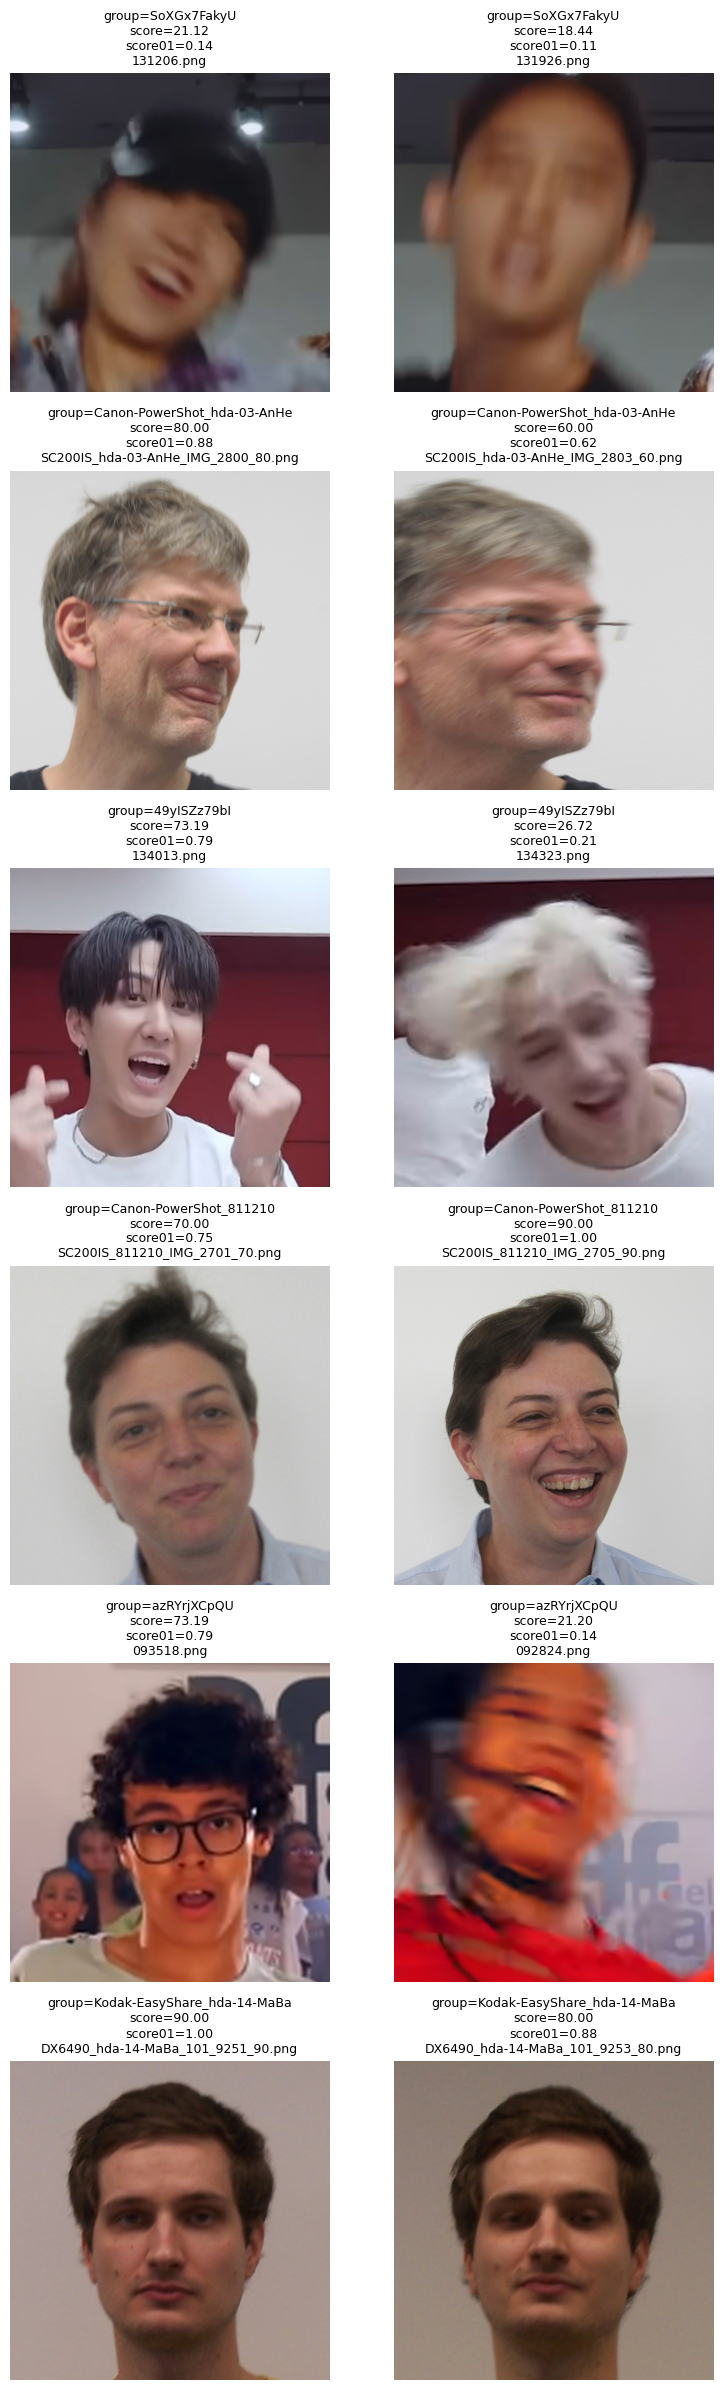

In [8]:
# Copilot blob to display images from the defined groups - training and validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_groups_and_images(df, group_col="group", path_col="aligned_path",
                           n_groups=6, n_images_per_group=2, seed=0,
                           show_score_cols=("score", "score01"),
                           max_img_size=512):
    assert group_col in df.columns, f"Missing group column: {group_col}"
    assert path_col in df.columns, f"Missing path column: {path_col}"

    # Clean df a bit
    d = df.copy()
    d[group_col] = d[group_col].fillna("unknown").astype(str)

    # Keep only rows where file exists
    d = d[d[path_col].notna()].copy()
    d[path_col] = d[path_col].astype(str)
    d = d[d[path_col].map(lambda p: Path(p).exists())].copy()

    # 1) Print group counts
    counts = d[group_col].value_counts().rename_axis("group").reset_index(name="n")
    print("Top groups by count:")
    display(counts.head(20))

    # 2) Pick groups (random among those with enough images)
    eligible = counts[counts["n"] >= n_images_per_group]["group"].tolist()
    if len(eligible) == 0:
        raise ValueError(f"No groups have at least {n_images_per_group} images after filtering existing files.")

    rng = np.random.default_rng(seed)
    chosen_groups = rng.choice(eligible, size=min(n_groups, len(eligible)), replace=False)

    # 3) Sample images per chosen group and display
    rows = len(chosen_groups)
    cols = n_images_per_group

    plt.figure(figsize=(4*cols, 4*rows))
    plot_idx = 1

    for g in chosen_groups:
        sub = d[d[group_col] == g].sample(n=n_images_per_group, random_state=seed)

        for _, r in sub.iterrows():
            pth = r[path_col]
            img = Image.open(pth).convert("RGB")
            img.thumbnail((max_img_size, max_img_size))

            ax = plt.subplot(rows, cols, plot_idx)
            ax.imshow(img)
            ax.axis("off")

            # Title: group + optional score info + filename
            parts = [f"group={g}"]
            for sc in show_score_cols:
                if sc in d.columns:
                    try:
                        parts.append(f"{sc}={float(r[sc]):.2f}")
                    except Exception:
                        parts.append(f"{sc}={r[sc]}")
            parts.append(Path(pth).name)
            ax.set_title("\n".join(parts), fontsize=9)

            plot_idx += 1

    plt.tight_layout()
    plt.show()


print("Some images from the different groups")
show_groups_and_images(trainval_df, group_col="group", path_col="minimal_aligned_path", n_groups=6, n_images_per_group=2, seed=0)

#show_groups_and_images(test_df, group_col="group", path_col="aligned_path", n_groups=6, n_images_per_group=2, seed=0)


## The Model + helper functions

In [226]:
# ============================================================
# MODEL
# ============================================================

class ViTRegressor(nn.Module):
    def __init__(
        self,
        model_name,
        pool="cls",
        dropout=0.1,
        sigmoidActivation=True,
        img_size_override=None,
        dynamic_img_size=False,
    ):
        super().__init__()

        model_kwargs = {"pretrained": True, "num_classes": 0}

        if img_size_override is not None:
            model_kwargs["img_size"] = img_size_override

        if dynamic_img_size:
            model_kwargs["dynamic_img_size"] = True

        self.backbone = timm.create_model(model_name, **model_kwargs)
        self.pool = pool

        d = self.backbone.num_features
        head_layers = [nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, 1)]

        if sigmoidActivation:
            head_layers.append(nn.Sigmoid())

        self.head = nn.Sequential(*head_layers)

    def forward(self, x):
        feats = self.backbone(x)

        if feats.ndim == 3:
            feats = feats[:, 0] if self.pool == "cls" else feats[:, 1:].mean(1)

        feats = feats.contiguous()
        return self.head(feats).squeeze(1)


# ============================================================
# HELPERS
# ============================================================

def rmse(pred, targ):
    return torch.sqrt(F.mse_loss(pred, targ))

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

@lru_cache(maxsize=None)
def load_pil_cached(p: str):
    return PILImage.create(p)

def build_dls_for_run(
    trainval_df,
    valid_idx,
    model_name,
    bs,
    image_path_col="aligned_path",
    img_size_override=None,
    resize_mode="squish",   # squish / crop / pad
    do_light_aug=False,
    dynamic_img_size=False
):
    work_df = trainval_df.copy().reset_index(drop=False).rename(columns={"index": "_orig_idx"})

    if image_path_col not in work_df.columns:
        raise KeyError(f"Missing image path column: {image_path_col}")

    work_df = work_df[work_df[image_path_col].notna()].copy()
    work_df[image_path_col] = work_df[image_path_col].astype(str)
    work_df = work_df[work_df[image_path_col].map(lambda p: Path(p).exists())].reset_index(drop=True)

    valid_idx_set = set(valid_idx)
    new_valid_idx = work_df.index[work_df["_orig_idx"].isin(valid_idx_set)].tolist()

    if len(new_valid_idx) == 0:
        raise ValueError(
            f"No validation rows remain after filtering for image_path_col='{image_path_col}'."
        )

    tmp_model_kwargs = {"pretrained": True, "num_classes": 0}
    if img_size_override is not None:
        tmp_model_kwargs["img_size"] = img_size_override
    if dynamic_img_size:
        tmp_model_kwargs["dynamic_img_size"] = True

    tmp_model = timm.create_model(model_name, **tmp_model_kwargs)
    data_cfg = timm.data.resolve_model_data_config(tmp_model)

    default_img_size = data_cfg.get("input_size", (3, 518, 518))[1]
    img_size = img_size_override if img_size_override is not None else default_img_size

    mean = data_cfg.get("mean", (0.485, 0.456, 0.406))
    std = data_cfg.get("std", (0.229, 0.224, 0.225))

    def get_x_cached(row):
        return load_pil_cached(str(row[image_path_col]))

    if resize_mode == "pad":
        item_tfms = [Resize(img_size, method=ResizeMethod.Pad, pad_mode=PadMode.Zeros)]
    elif resize_mode == "crop":
        item_tfms = [Resize(img_size, method=ResizeMethod.Crop)]
    else:
        item_tfms = [Resize(img_size, method=ResizeMethod.Squish)]

    if do_light_aug:
        item_tfms.append(FlipItem(p=0.5))

    batch_tfms = []

    if do_light_aug:
        batch_tfms += [
            Brightness(max_lighting=0.03, p=0.25),
            Contrast(max_lighting=0.03, p=0.25),
        ]

    batch_tfms += [Normalize.from_stats(mean, std)]

    dblock = DataBlock(
        blocks=(ImageBlock, RegressionBlock),
        get_x=get_x_cached,
        get_y=ColReader("score01"),
        splitter=IndexSplitter(new_valid_idx),
        item_tfms=item_tfms,
        batch_tfms=batch_tfms
    )

    dls = dblock.dataloaders(
        work_df,
        bs=bs,
        num_workers=0,   # keep 0 because cache is per-process
        pin_memory=True
    )

    return dls, {
        "img_size": img_size,
        "default_img_size": default_img_size,
        "mean": mean,
        "std": std,
        "resize_mode": resize_mode,
        "do_light_aug": do_light_aug,
        "image_path_col": image_path_col,
        "n_after_path_filter": len(work_df),
        "n_valid_after_path_filter": len(new_valid_idx),
    }, work_df, new_valid_idx


def get_run_dir(run_name):
    run_dir = MODEL_ROOT / MODEL_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "checkpoints").mkdir(exist_ok=True)
    return run_dir


def make_json_safe(obj):
    if isinstance(obj, (str, int, float, bool)) or obj is None:
        return obj
    elif isinstance(obj, Path):
        return str(obj)
    elif isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    else:
        return repr(obj)


def save_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(obj), f, indent=2, ensure_ascii=False, sort_keys=True)


def save_history_csv(learn, out_path):
    values = learn.recorder.values

    if len(values) == 0:
        hist_df = pd.DataFrame()
        hist_df.to_csv(out_path, index=False)
        return hist_df

    metric_names = []
    for m in learn.metrics:
        if hasattr(m, "name"):
            metric_names.append(m.name)
        else:
            metric_names.append(getattr(m, "__name__", str(m)))

    rows = []
    for i, row in enumerate(values):
        rows.append([i] + list(row))

    n_cols = len(rows[0])

    expected_no_time = 1 + 2 + len(metric_names)
    expected_with_time = expected_no_time + 1

    if n_cols == expected_no_time:
        cols = ["epoch", "train_loss", "valid_loss"] + metric_names
    elif n_cols == expected_with_time:
        cols = ["epoch", "train_loss", "valid_loss"] + metric_names + ["time"]
    else:
        cols = ["epoch"] + [f"value_{i}" for i in range(1, n_cols)]

    hist_df = pd.DataFrame(rows, columns=cols)
    hist_df.to_csv(out_path, index=False)
    return hist_df


def save_predictions_csv(learn, dl, base_df, out_path, mixed_precision_enabled=False):
    with autocast("cuda", enabled=mixed_precision_enabled):
        preds, targs = learn.get_preds(dl=dl)

    pred01 = preds.squeeze().detach().cpu().numpy()
    targ01 = targs.squeeze().detach().cpu().numpy()

    pred_df = base_df.copy().reset_index(drop=True)
    pred_df["pred01"] = pred01
    pred_df["true01"] = targ01
    pred_df["pred_1090"] = from_01(pred01)
    pred_df["true_1090"] = from_01(targ01)
    pred_df["abs_err_01"] = np.abs(pred01 - targ01)
    pred_df["abs_err_1090"] = np.abs(pred_df["pred_1090"] - pred_df["true_1090"])
    pred_df.to_csv(out_path, index=False)

    metrics = {
        "mae_01": float(np.mean(np.abs(pred01 - targ01))),
        "rmse_01": float(np.sqrt(np.mean((pred01 - targ01) ** 2))),
        "mae_1090": float(np.mean(np.abs(pred_df["pred_1090"] - pred_df["true_1090"]))),
        "rmse_1090": float(np.sqrt(np.mean((pred_df["pred_1090"] - pred_df["true_1090"]) ** 2))),
        "pred01_min": float(np.min(pred01)),
        "pred01_max": float(np.max(pred01)),
    }

    return pred_df, metrics


def append_summary_row(row_dict):
    summary_path = MODEL_ROOT / MODEL_DIR / "summary_results.csv"
    row_df = pd.DataFrame([row_dict])

    if summary_path.exists():
        row_df.to_csv(summary_path, mode="a", header=False, index=False)
    else:
        row_df.to_csv(summary_path, index=False)


def run_already_completed(run_name):
    run_dir = MODEL_ROOT / MODEL_DIR / run_name
    metrics_path = run_dir / "metrics.json"
    return metrics_path.exists()


def mark_run_complete(run_name):
    run_dir = MODEL_ROOT / MODEL_DIR / run_name
    flag_path = run_dir / "run_complete.flag"
    flag_path.write_text("completed\n", encoding="utf-8")


# ============================================================
# SPLITTERS / TRAINABLE-SCOPE HELPERS
# ============================================================

def vit_splitter(m):
    return [params(m.backbone), params(m.head)]

def filter_valid_image_paths(df, image_path_col):
    d = df.copy()

    if image_path_col not in d.columns:
        raise KeyError(f"Missing image path column: {image_path_col}")

    d = d[d[image_path_col].notna()].copy()
    d[image_path_col] = d[image_path_col].astype(str)
    d = d[d[image_path_col].map(lambda p: Path(p).exists())].reset_index(drop=True)

    return d

def count_trainable_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def get_backbone_blocks(backbone):
    if hasattr(backbone, "blocks"):
        return backbone.blocks
    raise AttributeError(f"Backbone of type {type(backbone)} does not expose `.blocks`.")

def vit_last_n_blocks_splitter(m, n_last_blocks=4):
    """
    Returns 3 parameter groups:
      1) early backbone params
      2) last n transformer blocks (+ final norm)
      3) regression head
    """
    blocks = get_backbone_blocks(m.backbone)
    n_blocks_total = len(blocks)
    n_last_blocks = min(n_last_blocks, n_blocks_total)
    cutoff = n_blocks_total - n_last_blocks

    early_params = []
    last_params = []
    head_params = list(m.head.parameters())

    for name, p in m.backbone.named_parameters():
        assigned = False

        if name.startswith("blocks."):
            block_idx = int(name.split(".")[1])
            if block_idx < cutoff:
                early_params.append(p)
            else:
                last_params.append(p)
            assigned = True

        if not assigned and (name.startswith("norm.") or name.startswith("fc_norm.")):
            last_params.append(p)
            assigned = True

        if not assigned:
            early_params.append(p)

    return [early_params, last_params, head_params]

def set_trainable_scope(model, fine_tune_scope="full", n_last_blocks=4, train_backbone_norm=True):
    """
    fine_tune_scope:
      - 'full'          : full backbone + head trainable
      - 'head_only'     : only regression head trainable
      - 'last_n_blocks' : last n transformer blocks + head trainable
    """

    # Freeze everything first
    for p in model.backbone.parameters():
        p.requires_grad = False
    for p in model.head.parameters():
        p.requires_grad = False

    # Always train the regression head
    for p in model.head.parameters():
        p.requires_grad = True

    if fine_tune_scope == "full":
        for p in model.backbone.parameters():
            p.requires_grad = True

    elif fine_tune_scope == "head_only":
        pass

    elif fine_tune_scope == "last_n_blocks":
        blocks = get_backbone_blocks(model.backbone)
        n_blocks_total = len(blocks)
        n_last_blocks = min(n_last_blocks, n_blocks_total)

        for blk in blocks[-n_last_blocks:]:
            for p in blk.parameters():
                p.requires_grad = True

        if train_backbone_norm:
            if hasattr(model.backbone, "norm") and model.backbone.norm is not None:
                for p in model.backbone.norm.parameters():
                    p.requires_grad = True

            if hasattr(model.backbone, "fc_norm") and model.backbone.fc_norm is not None:
                for p in model.backbone.fc_norm.parameters():
                    p.requires_grad = True

    else:
        raise ValueError(f"Unsupported fine_tune_scope: {fine_tune_scope}")

def print_trainable_scope_summary(model):
    backbone_total = sum(p.numel() for p in model.backbone.parameters())
    backbone_trainable = count_trainable_params(model.backbone)

    head_total = sum(p.numel() for p in model.head.parameters())
    head_trainable = count_trainable_params(model.head)

    print("\n=== Trainable scope summary ===")
    print(f"Backbone trainable: {backbone_trainable:,} / {backbone_total:,}")
    print(f"Head trainable:     {head_trainable:,} / {head_total:,}")
    print(f"Total trainable:    {backbone_trainable + head_trainable:,}")

## Split sanity check for protocol 1 and 2

In [274]:
## sanity check?
def print_edamb_protocol_summary(trainval_df, test_df):
    print("\n===== TRAINVAL EDAMB =====")
    tr_ed = trainval_df[trainval_df["source"] == "EDAMB"].copy()
    te_ed = test_df[test_df["source"] == "EDAMB"].copy()

    if len(tr_ed):
        print("Locations:", tr_ed["edamb_location"].value_counts(dropna=False).to_dict())
        print("Cameras:", tr_ed["edamb_camera"].value_counts(dropna=False).to_dict())
        print("Unique subjects:", tr_ed["edamb_subject_id"].nunique())

    print("\n===== TEST EDAMB =====")
    if len(te_ed):
        print("Locations:", te_ed["edamb_location"].value_counts(dropna=False).to_dict())
        print("Cameras:", te_ed["edamb_camera"].value_counts(dropna=False).to_dict())
        print("Unique subjects:", te_ed["edamb_subject_id"].nunique())

    train_subj = set(tr_ed["edamb_subject_id"].dropna().astype(str))
    test_subj = set(te_ed["edamb_subject_id"].dropna().astype(str))
    print("\nTrain/Test subject overlap:", len(train_subj & test_subj))

print_edamb_protocol_summary(trainval_df, test_df)


===== TRAINVAL EDAMB =====
Locations: {'HDA': 364, 'Essen': 350}
Cameras: {'Canon-EOS50D': 714}
Unique subjects: 35

===== TEST EDAMB =====
Locations: {'HDA': 295, 'Essen': 145}
Cameras: {'Canon-SC200IS': 234, 'Kodak-DX6490': 206}
Unique subjects: 35

Train/Test subject overlap: 35


## Main training function and saving info and config and test/train MAE to file(s)

In [235]:
# ============================================================
# MAIN TRAINING FUNCTION
# ============================================================

def train_one_run(run_cfg):
    # --------------------------------------------------------
    # 1) Read config with defaults
    # --------------------------------------------------------
    run_name = run_cfg["run_name"]
    force_rerun = run_cfg.get("force_rerun", False)
    seed=run_cfg.get("seed", SEED)

    fine_tune_scope = run_cfg.get("fine_tune_scope", "full")
    n_last_blocks = run_cfg.get("n_last_blocks", 4)
    train_backbone_norm = run_cfg.get("train_backbone_norm", True)
    lr_backbone = run_cfg.get("lr_backbone", None)
    lr_head = run_cfg.get("lr_head", None)

    # Skip if already completed
    if run_already_completed(run_name) and not force_rerun:
        print(f"\nSkipping run (already completed): {run_name}")
        run_dir = MODEL_ROOT / MODEL_DIR / run_name
        metrics_path = run_dir / "metrics.json"
        metrics = None
        if metrics_path.exists():
            with open(metrics_path, "r", encoding="utf-8") as f:
                metrics = json.load(f)
        return {
            "run_name": run_name,
            "run_dir": run_dir,
            "metrics": metrics,
            "skipped": True
        }

    model_name = run_cfg["model_name"]
    bs = run_cfg.get("bs", 6)
    loss_func = run_cfg.get("loss_func", MSELossFlat())
    dropout = run_cfg.get("dropout", 0.1)
    sigmoid = run_cfg.get("sigmoid", True)
    pool = run_cfg.get("pool", "cls")
    image_path_col = run_cfg.get("image_path_col", "aligned_path")

    wd = run_cfg.get("wd", 1e-2)
    img_size_override = run_cfg.get("img_size_override", None)
    resize_mode = run_cfg.get("resize_mode", "squish")
    do_light_aug = run_cfg.get("do_light_aug", False)
    dynamic_img_size = run_cfg.get("dynamic_img_size", False)

    training_mode = run_cfg.get("training_mode", "full_finetune")

    # full-finetune settings
    epochs = run_cfg.get("epochs", 15)
    lr_max = run_cfg.get("lr_max", None)

    # transfer-learning settings
    freeze_epochs = run_cfg.get("freeze_epochs", 5)
    unfreeze_epochs = run_cfg.get("unfreeze_epochs", 15)
    use_lr_find = run_cfg.get("use_lr_find", True)
    stage1_lr = run_cfg.get("stage1_lr", None)
    stage2_lr_low = run_cfg.get("stage2_lr_low", None)
    stage2_lr_high = run_cfg.get("stage2_lr_high", None)

    notes = run_cfg.get("notes", "")
    tags = run_cfg.get("tags", [])
    mixed_precision_enabled = run_cfg.get("mixed_precision_enabled", False)
    early_stop_patience = run_cfg.get("early_stop_patience", 3)

    # IMPORTANT:
    # use active global split metadata by default
    split_mode = run_cfg.get("split_mode", ACTIVE_SPLIT_MODE)
    split_protocol = run_cfg.get("split_protocol", ACTIVE_SPLIT_PROTOCOL)
    held_out_source = run_cfg.get("held_out_source", ACTIVE_HELD_OUT_SOURCE)
    valid_split_col = run_cfg.get("valid_split_col", VALID_SPLIT_COL)
    
    # Safety check to prevent metadata/run-config mismatch
    if split_mode != ACTIVE_SPLIT_MODE:
        raise ValueError(
            f"run_cfg split_mode={split_mode} does not match ACTIVE_SPLIT_MODE={ACTIVE_SPLIT_MODE}. "
            "Change SPLIT_MODE and rerun the split block, or use matching run configs."
        )
    if held_out_source != ACTIVE_HELD_OUT_SOURCE:
        raise ValueError(
            f"run_cfg held_out_source={held_out_source} does not match "
            f"ACTIVE_HELD_OUT_SOURCE={ACTIVE_HELD_OUT_SOURCE}. "
            "Change HELD_OUT_SOURCE and rerun the split block, or use matching run configs."
        )
    # --------------------------------------------------------
    # 2) Setup run folder
    # --------------------------------------------------------
    run_dir = get_run_dir(run_name)
    checkpoints_dir = run_dir / "checkpoints"

    save_json(run_dir / "config.json", run_cfg)

    # --------------------------------------------------------
    # 3) Reset memory / set seeds
    # --------------------------------------------------------
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    set_all_seeds(SEED)

    # --------------------------------------------------------
    # 4) Build dataloaders
    # --------------------------------------------------------
    dls, data_meta, filtered_trainval_df, filtered_valid_idx = build_dls_for_run(
        trainval_df=trainval_df,
        valid_idx=valid_idx,
        model_name=model_name,
        bs=bs,
        image_path_col=image_path_col,
        img_size_override=img_size_override,
        resize_mode=resize_mode,
        do_light_aug=do_light_aug,
        dynamic_img_size=dynamic_img_size
    )

    print("Image path column:", image_path_col)
    print("Rows after path filtering:", data_meta.get("n_after_path_filter", "not available"))
    print("Validation rows after path filtering:", data_meta.get("n_valid_after_path_filter", "not available"))

    # --------------------------------------------------------
    # 5) Build model + learner
    # --------------------------------------------------------
    model = ViTRegressor(
        model_name=model_name,
        pool=pool,
        dropout=dropout,
        sigmoidActivation=sigmoid,
        img_size_override=img_size_override,
        dynamic_img_size=dynamic_img_size
    )

    set_trainable_scope(
        model,
        fine_tune_scope=fine_tune_scope,
        n_last_blocks=n_last_blocks,
        train_backbone_norm=train_backbone_norm
    )

    # commented this out because I will not use train head/ bodu / N last blocks approach - sticking to full finetuning.
    #print_trainable_scope_summary(model)

    # defaults for metadata/debug
    n_param_groups = None
    after_freeze_backbone = None
    after_freeze_head = None
    freeze_debug = {}

    if fine_tune_scope == "last_n_blocks":
        splitter_fn = partial(vit_last_n_blocks_splitter, n_last_blocks=n_last_blocks)
        splitter_used = "vit_last_n_blocks_splitter"
    else:
        splitter_fn = vit_splitter
        splitter_used = "vit_splitter"

    learn = Learner(
        dls,
        model,
        loss_func=loss_func,
        metrics=[mae, rmse],
        path=run_dir,
        model_dir="checkpoints",
        splitter=splitter_fn
    )

    if torch.cuda.is_available():
        learn.to("cuda")

    # create optimizer now so param-group info is available
    learn.create_opt()
    n_param_groups = len(learn.opt.param_lists)

    after_freeze_backbone = count_trainable_params(model.backbone)
    after_freeze_head = count_trainable_params(model.head)

    freeze_debug = {
        "splitter_used": splitter_used,
        "n_param_groups": n_param_groups,
        "backbone_trainable_params": after_freeze_backbone,
        "head_trainable_params": after_freeze_head,
    }

    # --------------------------------------------------------
    # 6) Learning-rate plan
    # --------------------------------------------------------
    if training_mode == "full_finetune":
        if use_lr_find:
            with autocast("cuda", enabled=mixed_precision_enabled):
                lr_min, lr_steep = learn.lr_find(
                    suggest_funcs=(minimum, steep),
                    show_plot=False
                )
            if lr_max is None:
                lr_max = float(lr_steep)
        else:
            if lr_max is None and not (
                fine_tune_scope == "last_n_blocks" and lr_backbone is not None and lr_head is not None
            ):
                raise ValueError(
                    "If use_lr_find=False in full_finetune mode, provide lr_max "
                    "or provide lr_backbone/lr_head for last_n_blocks."
                )

    elif training_mode == "transfer_learning":
        if use_lr_find:
            with autocast("cuda", enabled=mixed_precision_enabled):
                lr_min, lr_steep = learn.lr_find(
                    suggest_funcs=(minimum, steep),
                    show_plot=False
                )

            if stage1_lr is None:
                stage1_lr = float(lr_steep)
            if stage2_lr_low is None:
                stage2_lr_low = float(lr_steep / 100)
            if stage2_lr_high is None:
                stage2_lr_high = float(lr_steep / 10)
        else:
            if stage1_lr is None or stage2_lr_low is None or stage2_lr_high is None:
                raise ValueError(
                    "If use_lr_find=False in transfer_learning mode, you must provide "
                    "stage1_lr, stage2_lr_low, and stage2_lr_high"
                )
    else:
        raise ValueError(f"Unsupported training_mode: {training_mode}")

    lr_plan = {
        "lr_max": lr_max,
        "lr_backbone": lr_backbone,
        "lr_head": lr_head,
        "stage1_lr": stage1_lr,
        "stage2_lr_low": stage2_lr_low,
        "stage2_lr_high": stage2_lr_high
    }
    save_json(run_dir / "lr_plan.json", lr_plan)

    # --------------------------------------------------------
    # 7) Train model
    # --------------------------------------------------------
    save_cb = SaveModelCallback(monitor="mae", comp=np.less, fname="best_mae")
    early_stop_cb = EarlyStoppingCallback(monitor="mae", comp=np.less, patience=early_stop_patience)

    print(f"\n===== RUN: {run_name} =====")
    print("Protocol:", split_protocol)
    print("Held-out source (test source):", held_out_source)
    print("Split mode:", split_mode)
    print("Valid split col:", valid_split_col)
    print("Training mode:", training_mode)
    print("Using model:", model_name)
    print("Batch size:", bs)
    print("Pool:", pool)
    print("Seed:", seed)
    print("Loss function:", loss_func)
    print("Dropout:", dropout)
    print("Sigmoid:", sigmoid)
    print("Image path column:", image_path_col)
    print("IMG_SIZE:", data_meta["img_size"])
    print("Resize mode:", resize_mode)
    print("Light augmentation:", do_light_aug)
    print("Weight decay:", wd)
    
    #print("fine_tune_scope:", fine_tune_scope)
    #print("n_last_blocks:", n_last_blocks)
   # print("train_backbone_norm:", train_backbone_norm)
    #print("lr_backbone:", lr_backbone)
    #print("lr_head:", lr_head)

    if training_mode == "full_finetune":
        print("Full fine-tuning epochs:", epochs)
        if use_lr_find:
            print("lr_find used: lr_min, lr_steep =", lr_min, lr_steep)
        else:
            print("lr_max:", lr_max)

        # differential LR for last_n_blocks mode if provided
        if fine_tune_scope == "last_n_blocks" and lr_backbone is not None and lr_head is not None:
            lr_to_use = slice(lr_backbone, lr_head)
        else:
            lr_to_use = lr_max

        with autocast("cuda", enabled=mixed_precision_enabled):
            learn.fit_one_cycle(
                epochs,
                lr_max=lr_to_use,
                wd=wd,
                cbs=[save_cb, early_stop_cb]
            )

    elif training_mode == "transfer_learning":
        print("Stage 1 lr:", stage1_lr)
        print("Stage 2 lr slice:", stage2_lr_low, stage2_lr_high)

        learn.freeze()
        print("\nStage 1: freeze")
        print("Backbone trainable:", count_trainable_params(learn.model.backbone))
        print("Head trainable:", count_trainable_params(learn.model.head))

        with autocast("cuda", enabled=mixed_precision_enabled):
            learn.fit_one_cycle(freeze_epochs, lr_max=stage1_lr, wd=wd)

        learn.unfreeze()
        print("\nStage 2: unfreeze")
        print("Backbone trainable:", count_trainable_params(learn.model.backbone))
        print("Head trainable:", count_trainable_params(learn.model.head))

        with autocast("cuda", enabled=mixed_precision_enabled):
            learn.fit_one_cycle(
                unfreeze_epochs,
                lr_max=slice(stage2_lr_low, stage2_lr_high),
                wd=wd,
                cbs=[save_cb, early_stop_cb]
            )

    # --------------------------------------------------------
    # 8) Save final model + learner export
    # --------------------------------------------------------
    learn.save(run_name)
    learn.export(run_dir / f"{run_name}.pkl")

    # --------------------------------------------------------
    # 9) Save training history
    # --------------------------------------------------------
    history_df = save_history_csv(learn, run_dir / "training_history.csv")

    # --------------------------------------------------------
    # 10) Load best model before exporting predictions
    # --------------------------------------------------------
    best_ckpt_path = checkpoints_dir / "best_mae.pth"
    if best_ckpt_path.exists():
        learn.load("best_mae")

    # --------------------------------------------------------
    # 11) Validation predictions
    # --------------------------------------------------------
    valid_base_df = filtered_trainval_df.iloc[filtered_valid_idx].copy().reset_index(drop=True)

    valid_pred_df, valid_metrics = save_predictions_csv(
        learn=learn,
        dl=dls.valid,
        base_df=valid_base_df,
        out_path=run_dir / "valid_predictions.csv",
        mixed_precision_enabled=mixed_precision_enabled
    )

    # --------------------------------------------------------
    # 12) Test predictions
    # --------------------------------------------------------
    filtered_test_df = filter_valid_image_paths(test_df, image_path_col).copy().reset_index(drop=True)

    test_dl = dls.test_dl(filtered_test_df, with_labels=True)

    test_pred_df, test_metrics = save_predictions_csv(
        learn=learn,
        dl=test_dl,
        base_df=filtered_test_df.copy().reset_index(drop=True),
        out_path=run_dir / "test_predictions.csv",
        mixed_precision_enabled=mixed_precision_enabled
    )

    # --------------------------------------------------------
    # 13) Save metrics
    # --------------------------------------------------------
    if training_mode == "full_finetune":
        total_requested_epochs = epochs
    else:
        total_requested_epochs = freeze_epochs + unfreeze_epochs


    if training_mode == "full_finetune":
        stage1_lr_var = "N/A"
        stage2_lr_low_var = "N/A"
        stage2_lr_high_var = "N/A"
        freeze_epochs_var = "N/A"
        unfreeze_epochs_var = "N/A"
        epochs_var = epochs
        lr_max_var = lr_max
        
    actual_epochs_ran = len(history_df)
    stopped_early = actual_epochs_ran < total_requested_epochs

    best_valid_mae = float(getattr(save_cb, "best", np.nan))

    metrics = {
        "run_name": run_name,
        "timestamp": dt.datetime.now().isoformat(),
        "held_out_source": held_out_source,
        "n_total": int(len(df)),
        "n_trainval": int(len(trainval_df)),
        "n_valid": int(len(valid_idx)),
        "n_test": int(len(test_df)),
        "valid_mae_01": valid_metrics["mae_01"],
        "valid_rmse_01": valid_metrics["rmse_01"],
        "valid_mae_1090": valid_metrics["mae_1090"],
        "valid_rmse_1090": valid_metrics["rmse_1090"],
        "test_mae_01": test_metrics["mae_01"],
        "test_rmse_01": test_metrics["rmse_01"],
        "test_mae_1090": test_metrics["mae_1090"],
        "test_rmse_1090": test_metrics["rmse_1090"],
        "best_valid_mae_during_training": best_valid_mae,
        "pred01_min_test": test_metrics["pred01_min"],
        "pred01_max_test": test_metrics["pred01_max"],
        "requested_total_epochs": total_requested_epochs,
        "actual_epochs_ran": actual_epochs_ran,
        "stopped_early": stopped_early,
        "img_size_override": img_size_override,
        "split_mode": split_mode,
        "split_protocol": split_protocol,
        "valid_split_col": valid_split_col,
        "fine_tune_scope": fine_tune_scope,
    }

    save_json(run_dir / "metrics.json", metrics)
    mark_run_complete(run_name)

    # --------------------------------------------------------
    # 14) Save runtime metadata
    # --------------------------------------------------------
    runtime_meta = {
        "timestamp": dt.datetime.now().isoformat(),

        # system info
        "python_version": platform.python_version(),
        "torch_version": torch.__version__,
        "timm_version": timm.__version__,
        "cuda_version": torch.version.cuda,
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "gpu_count": torch.cuda.device_count() if torch.cuda.is_available() else 0,

        # data / dataloaders
        "manifest_path": str(MANIFEST),
        "trainval_rows": len(trainval_df),
        "test_rows": len(test_df),
        "valid_pct": VALID_PCT,
        "seed": SEED,
        "image_path_col": image_path_col,
        "held_out_source": held_out_source,
        "resize_mode": resize_mode,
        "do_light_aug": do_light_aug,
        "img_size_effective": data_meta["img_size"],
        "img_size_default_model": data_meta["default_img_size"],
        "img_size_override": img_size_override,
        "dynamic_img_size": dynamic_img_size,
        "mean": data_meta["mean"],
        "std": data_meta["std"],
        "rows_after_path_filter": data_meta["n_after_path_filter"],
        "validation_rows_after_filter": data_meta["n_valid_after_path_filter"],

        # model info
        "model_name": model_name,
        "pretrained": True,
        "pooling": pool,
        "dropout": dropout,
        "sigmoid_head": sigmoid,
        "num_features": learn.model.backbone.num_features,
        "patch_size": getattr(learn.model.backbone, "patch_size", None),
        "splitter_used": splitter_used,
        "head_structure": str(learn.model.head),
        "fine_tune_scope": fine_tune_scope,


        # split info
        "split_mode": split_mode,
        "split_protocol": split_protocol,
        "valid_split_col": valid_split_col,

        # training setup
        "training_mode": training_mode,
        "batch_size": bs,
        "loss_function": repr(loss_func),
        "weight_decay": wd,
        "mixed_precision": mixed_precision_enabled,
        "early_stop_patience": early_stop_patience,
        "stopped_early": stopped_early,
        "requested_total_epochs": total_requested_epochs,
        "actual_epochs_ran": actual_epochs_ran,
        "epochs": epochs,
        "lr_max": lr_max,

        # debug info
        "freeze_debug": freeze_debug,

        # full run config
        "full_run_config": run_cfg,

        # notes
        "notes": notes,
        "tags": tags,
    }

    save_json(run_dir / "run_metadata.json", runtime_meta)

    # --------------------------------------------------------
    # 15) Append one-row summary CSV
    # --------------------------------------------------------

    generalization_gap = abs(test_metrics["mae_01"] - best_valid_mae)
    rerun_id=run_cfg.get("rerun_id")
 

    summary_row = {
        "timestamp": dt.datetime.now().isoformat(),
        "run_name": run_name,
        "model_name": model_name,
        "bs": bs,
        "loss_func": repr(loss_func),
        "dropout": dropout,
        "sigmoid": sigmoid,
        "pool": pool,
        "preprocessed_type": image_path_col,
        "wd": wd,
        "img_size": data_meta["img_size"],
        "resize_mode": resize_mode,
        "do_light_aug": do_light_aug,
        "test_mae_01": test_metrics["mae_01"],
        "test_mae_1090": test_metrics["mae_1090"],
        "test_rmse_1090": test_metrics["rmse_1090"],
        "best_valid_mae_during_training": best_valid_mae,
        "generalization_gap": generalization_gap,
        "held_out_source": held_out_source,
        "split_protocol": split_protocol,
        "training_mode": training_mode,
        "epochs": epochs,
        "stopped_early": stopped_early,
        "actual_epochs_ran": actual_epochs_ran,
        "rerun_id": rerun_id,
        "seed": seed,
        "use_lr_find": use_lr_find,
        "lr_max": lr_max_var,
        "run_dir": str(run_dir),
    }

    append_summary_row(summary_row)

    print(f"\nFinished run: {run_name}")
    print("Test MAE (0-1):", test_metrics["mae_01"])
    print("Test RMSE (0-1):", test_metrics["rmse_01"])
    print("Saved to:", run_dir)

    return {
        "run_name": run_name,
        "run_dir": run_dir,
        "metrics": metrics,
        "history_df": history_df,
        "valid_pred_df": valid_pred_df,
        "test_pred_df": test_pred_df,
        "skipped": False
    }

## Base run parameters/config
Will /can override later based on defined runs. see RUNS array


In [229]:
# ============================================================
# BASE RUN CONFIG
# ============================================================

BASE_RUN = {
    "model_name": "vit_small_patch14_dinov2.lvd142m",
    "bs": 6,
    "loss_func": MSELossFlat(),
    "dropout": 0.1,
    "sigmoid": True,
    "pretrained": True,
    "pool": "mean",
    "image_path_col": "minimal_aligned_path",

    # image settings
    "wd": 1e-3,
    "img_size_override": None,
    "resize_mode": "squish",
    "do_light_aug": False,
    "dynamic_img_size": False,

    # training mode
    "training_mode": "full_finetune",

    # support full / head-only / last-n-blocks
    "fine_tune_scope": "full",   # "full", "head_only", "last_n_blocks"
    "n_last_blocks": 4,
    "train_backbone_norm": True,
    "lr_backbone": None,
    "lr_head": None,

    # full-finetune settings
    "epochs": 15,
    "lr_max": None,

    # transfer-learning settings
    "freeze_epochs": 3,
    "unfreeze_epochs": 15,
    "use_lr_find": False,
    "stage1_lr": 1e-4,
    "stage2_lr_low": 1e-6,
    "stage2_lr_high": 1e-5,

    "mixed_precision_enabled": False,
    "early_stop_patience": 3,
}


## the run-index / config signature (not used??()

In [7]:

# ============================================================
# EXISTING-RUN INDEX
# ============================================================

def _loss_to_string(loss_obj):
    if isinstance(loss_obj, str):
        return loss_obj
    try:
        return repr(loss_obj)
    except Exception:
        return str(loss_obj)

def config_signature(cfg):
    # IMPORTANT:
    # include fine_tune_scope / n_last_blocks / lr_backbone / lr_head
    # so head_only != full_finetune in the reuse logic
    sig = {
        "model_name": cfg.get("model_name"),
        "training_mode": cfg.get("training_mode"),
        "image_path_col": cfg.get("image_path_col"),
        "loss_func": _loss_to_string(cfg.get("loss_func")),
        "bs": cfg.get("bs"),
        "dropout": cfg.get("dropout"),
        "sigmoid": cfg.get("sigmoid", True),
        "pool": cfg.get("pool"),
        "wd": cfg.get("wd"),
        "img_size_override": cfg.get("img_size_override"),
        "dynamic_img_size": cfg.get("dynamic_img_size", False),
        "resize_mode": cfg.get("resize_mode"),
        "do_light_aug": cfg.get("do_light_aug"),
        "epochs": cfg.get("epochs"),
        "lr_max": cfg.get("lr_max"),
        "early_stop_patience": cfg.get("early_stop_patience"),

        # split-defining fields
        "held_out_source": cfg.get("held_out_source"),
        "split_mode": cfg.get("split_mode"),
        "split_protocol": cfg.get("split_protocol"),
        "valid_split_col": cfg.get("valid_split_col"),

        # NEW: adaptation-scope fields
        "fine_tune_scope": cfg.get("fine_tune_scope"),
    }
    return json.dumps(sig, sort_keys=True, default=str)

    # index existing runs
def build_existing_run_index(
    subfolders=None,
    include_root=False,
    recurse_in_subfolders=True,
    verbose=True,
):
    run_root = MODEL_ROOT / MODEL_DIR
    index = {}
    seen_dirs = set()

    if not run_root.exists():
        print(f"[WARNING] run_root does not exist: {run_root}")
        return index

    def add_run_dir(run_dir):
        run_dir = run_dir.resolve()
        if run_dir in seen_dirs:
            return
        seen_dirs.add(run_dir)

        cfg_path = run_dir / "config.json"
        metrics_path = run_dir / "metrics.json"

        if not cfg_path.exists() or not metrics_path.exists():
            return

        try:
            with open(cfg_path, "r", encoding="utf-8") as f:
                cfg = json.load(f)

            with open(metrics_path, "r", encoding="utf-8") as f:
                metrics = json.load(f)

            sig = config_signature(cfg)
            index[sig] = {
                "run_name": cfg.get("run_name", run_dir.name),
                "run_dir": str(run_dir),
                "config": cfg,
                "metrics": metrics,
            }

        except Exception as e:
            print(f"Could not read existing run in {run_dir}: {e}")

    if include_root:
        if verbose:
            print(f"[ROOT DIRECT ONLY] {run_root.resolve()}")
        for child in run_root.iterdir():
            if child.is_dir():
                add_run_dir(child)

    if subfolders is not None:
        for sub in subfolders:
            sub_path = (run_root / sub).resolve()

            if not sub_path.exists() or not sub_path.is_dir():
                print(f"[WARNING] Subfolder not found or not a directory: {sub_path}")
                continue

            if verbose:
                mode = "RECURSIVE" if recurse_in_subfolders else "DIRECT ONLY"
                print(f"[SUBFOLDER {mode}] {sub_path}")

            if recurse_in_subfolders:
                for cfg_path in sub_path.rglob("config.json"):
                    add_run_dir(cfg_path.parent)
            else:
                for child in sub_path.iterdir():
                    if child.is_dir():
                        add_run_dir(child)

    return index


SEARCH_SUBFOLDERS = [""]
EXISTING_RUN_INDEX = build_existing_run_index(
    subfolders=SEARCH_SUBFOLDERS,
    include_root=True,
    recurse_in_subfolders=False,
    verbose=True
)

print("Existing completed equivalent-run signatures found:", len(EXISTING_RUN_INDEX))
for info in EXISTING_RUN_INDEX.values():
    print(f"{info['run_name']} -> {info['run_dir']}")

[ROOT DIRECT ONLY] /margrethe/code/models/ViT_motion_blur_runs_LOSO
[SUBFOLDER DIRECT ONLY] /margrethe/code/models/ViT_motion_blur_runs_LOSO
Existing completed equivalent-run signatures found: 0


## ACTIVE SPLIT CONFIG + CONFIG LOADING FROM EXISTING RUN PATHS

In [315]:
# ============================================================
# ACTIVE SPLIT CONFIG + CONFIG LOADING FROM EXISTING RUN PATHS
# ============================================================

# ------------------------------------------------------------
# Split-common configs
# ------------------------------------------------------------
P1_COMMON = {
    "split_mode": "edamb_protocol1",
    "split_protocol": "EDAMB_protocol1_cross_location",
    "held_out_source": None,
    "valid_split_col": "split_unit",
    "force_rerun": True,
    "notes": "Protocol 1 - EDAMB only trainval (HDA) / test (Essen)",
}

P2_COMMON = {
    "split_mode": "edamb_protocol2",
    "split_protocol": "EDAMB_protocol2_cross_camera",
    "held_out_source": None,
    "valid_split_col": "split_unit",
    "force_rerun": True,
    "notes": "Protocol 2 - EDAMB only trainval (Canon-EOS50D) / test (Canon-SC200IS + Kodak-DX6490)",
}

def make_loso_common(held_out_source):
    held_out_source = str(held_out_source).strip()
    if held_out_source not in KNOWN_SOURCES:
        raise ValueError(f"Unsupported held_out_source={held_out_source!r}")

    train_sources = [s for s in KNOWN_SOURCES if s != held_out_source]

    return {
        "split_mode": "leave_one_source_out",
        "split_protocol": f"leave_one_source_out__test_{held_out_source}",
        "held_out_source": held_out_source,
        "valid_split_col": "split_unit",
        "force_rerun": True,
        "notes": f"LOSO: train/val on {train_sources}, test on [{held_out_source}]",
    }

def get_active_split_common():
    if SPLIT_MODE == "leave_one_source_out":
        return make_loso_common(HELD_OUT_SOURCE)
    elif SPLIT_MODE == "edamb_protocol1":
        return P1_COMMON
    elif SPLIT_MODE == "edamb_protocol2":
        return P2_COMMON
    else:
        raise ValueError(f"Unsupported SPLIT_MODE: {SPLIT_MODE}")

def get_active_split_tag():
    if SPLIT_MODE == "leave_one_source_out":
        return f"loso_{HELD_OUT_SOURCE.lower()}"
    elif SPLIT_MODE == "edamb_protocol1":
        return "p1"
    elif SPLIT_MODE == "edamb_protocol2":
        return "p2"
    else:
        raise ValueError(f"Unsupported SPLIT_MODE: {SPLIT_MODE}")

ACTIVE_SPLIT_COMMON = get_active_split_common()
ACTIVE_SPLIT_TAG = get_active_split_tag()

print("ACTIVE_SPLIT_COMMON =", ACTIVE_SPLIT_COMMON)
print("ACTIVE_SPLIT_TAG    =", ACTIVE_SPLIT_TAG)

# ------------------------------------------------------------
# Helpers for loading config.json from a previous run path
# ------------------------------------------------------------
def _resolve_run_dir_and_config_path(path_like):
    p = Path(path_like)

    # Allow either:
    # - /path/to/run_dir
    # - /path/to/run_dir/config.json
    if p.is_file() and p.name == "config.json":
        cfg_path = p
        run_dir = p.parent
    else:
        cfg_path = p / "config.json"
        run_dir = p

    if not cfg_path.exists():
        raise FileNotFoundError(
            f"Could not find config.json. Looked for: {cfg_path}"
        )

    return run_dir, cfg_path

def restore_loss_func(loss_obj):
    """
    Converts saved config loss representations back into actual callable loss functions.
    Your saved config.json stores unknown Python objects via repr(...), so loss_func
    often comes back as a string such as 'SmoothL1Loss()' or 'MSELossFlat()'.
    """
    if loss_obj is None:
        return MSELossFlat()

    if not isinstance(loss_obj, str):
        return loss_obj

    s = loss_obj.strip()

    # Robust matching against repr strings
    if "SmoothL1Loss" in s:
        return nn.SmoothL1Loss()
    if "MSELossFlat" in s:
        return MSELossFlat()
    if re.search(r"\bMSELoss\b", s):
        return nn.MSELoss()
    if re.search(r"\bL1Loss\b", s):
        return nn.L1Loss()
    if "HuberLoss" in s:
        return nn.HuberLoss()

    raise ValueError(
        f"Unsupported saved loss_func representation: {loss_obj!r}\n"
        "Add another mapping inside restore_loss_func(...) if needed."
    )

def load_saved_run_config(path_like, verbose=True):
    run_dir, cfg_path = _resolve_run_dir_and_config_path(path_like)

    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    # restore loss function if it was serialized as string
    cfg["loss_func"] = restore_loss_func(cfg.get("loss_func", None))

    # Keep provenance
    cfg["source_model_path"] = str(run_dir)
    cfg["source_model_name"] = cfg.get("run_name", run_dir.name)

    if verbose:
        print(f"[LOADED CONFIG] {run_dir}")
        print("  run_name:", cfg.get("run_name"))
        print("  model_name:", cfg.get("model_name"))
        print("  loss_func:", cfg.get("loss_func"))

    return cfg

def prepare_run_cfg_for_active_split(run_cfg, run_name_suffix=None, overrides=None):
    """
    Takes either:
    - a manually created run_cfg, or
    - a run_cfg loaded from an old run folder

    and forces it onto the CURRENTLY ACTIVE split selection.
    """
    cfg = dict(run_cfg)

    # Replace old split settings with active split settings
    cfg.update(ACTIVE_SPLIT_COMMON)

    # Optional overrides after split settings
    if overrides:
        cfg.update(overrides)

    # Ensure loss function is a callable, not a serialized string
    cfg["loss_func"] = restore_loss_func(cfg.get("loss_func", None))

    # Make run_name split-specific if desired
    old_run_name = cfg.get("run_name", "run")
    if run_name_suffix is None:
        run_name_suffix = ACTIVE_SPLIT_TAG

    if not old_run_name.endswith(f"__{run_name_suffix}"):
        cfg["run_name"] = f"{old_run_name}__{run_name_suffix}"

    return cfg

def build_runs_from_saved_paths(saved_run_paths, overrides=None, run_name_suffix=None, verbose=True):
    """
    Load one or more prior run configs from full paths and adapt them
    to the currently active split.
    """
    runs = []

    for p in saved_run_paths:
        base_cfg = load_saved_run_config(p, verbose=verbose)
        cfg = prepare_run_cfg_for_active_split(
            base_cfg,
            run_name_suffix=run_name_suffix,
            overrides=overrides
        )
        runs.append(cfg)

    return runs

# ------------------------------------------------------------
# Redefine config_signature so LOSO held-out source is part of uniqueness
# ------------------------------------------------------------
def _loss_to_string(loss_obj):
    if isinstance(loss_obj, str):
        return loss_obj
    try:
        return repr(loss_obj)
    except Exception:
        return str(loss_obj)

def config_signature(cfg):
    sig = {
        "model_name": cfg.get("model_name"),
        "training_mode": cfg.get("training_mode"),
        "image_path_col": cfg.get("image_path_col"),
        "loss_func": _loss_to_string(cfg.get("loss_func")),
        "bs": cfg.get("bs"),
        "dropout": cfg.get("dropout"),
        "sigmoid": cfg.get("sigmoid", True),
        "pool": cfg.get("pool"),
        "wd": cfg.get("wd"),
        "img_size_override": cfg.get("img_size_override"),
        "dynamic_img_size": cfg.get("dynamic_img_size", False),
        "resize_mode": cfg.get("resize_mode"),
        "do_light_aug": cfg.get("do_light_aug"),
        "epochs": cfg.get("epochs"),
        "lr_max": cfg.get("lr_max"),
        "early_stop_patience": cfg.get("early_stop_patience"),
        "rerun_id": cfg.get("rerun_id"),

        # split-defining fields
        "split_mode": cfg.get("split_mode"),
        "split_protocol": cfg.get("split_protocol"),
        "held_out_source": cfg.get("held_out_source"),
        "valid_split_col": cfg.get("valid_split_col"),

        # transfer-learning fields
        "freeze_epochs": cfg.get("freeze_epochs"),
        "unfreeze_epochs": cfg.get("unfreeze_epochs"),
        "stage1_lr": cfg.get("stage1_lr"),
        "stage2_lr_low": cfg.get("stage2_lr_low"),
        "stage2_lr_high": cfg.get("stage2_lr_high"),

        # adaptation-scope fields
        "fine_tune_scope": cfg.get("fine_tune_scope"),
        "n_last_blocks": cfg.get("n_last_blocks"),
        "train_backbone_norm": cfg.get("train_backbone_norm"),
        "lr_backbone": cfg.get("lr_backbone"),
        "lr_head": cfg.get("lr_head"),
    }
    return json.dumps(sig, sort_keys=True, default=str)

# ------------------------------------------------------------
# Rebuild existing-run index using the updated config_signature
# ------------------------------------------------------------
if "SEARCH_SUBFOLDERS" not in globals():
    SEARCH_SUBFOLDERS = [""]

EXISTING_RUN_INDEX = build_existing_run_index(
    subfolders=SEARCH_SUBFOLDERS,
    include_root=True,
    recurse_in_subfolders=False,
    verbose=True
)

print("Existing completed equivalent-run signatures found:", len(EXISTING_RUN_INDEX))
for info in list(EXISTING_RUN_INDEX.values())[:10]:
    print(f"{info['run_name']} -> {info['run_dir']}")

ACTIVE_SPLIT_COMMON = {'split_mode': 'edamb_protocol2', 'split_protocol': 'EDAMB_protocol2_cross_camera', 'held_out_source': None, 'valid_split_col': 'split_unit', 'force_rerun': True, 'notes': 'Protocol 2 - EDAMB only trainval (Canon-EOS50D) / test (Canon-SC200IS + Kodak-DX6490)'}
ACTIVE_SPLIT_TAG    = p2
[ROOT DIRECT ONLY] /margrethe/code/models/ViT_PROTOCOLS_reporting
[SUBFOLDER DIRECT ONLY] /margrethe/code/models/ViT_PROTOCOLS_reporting
Existing completed equivalent-run signatures found: 119
FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__p2_rerun4 -> /margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__p2_rerun4
FT_small_dinov2_mse_bs14_lr3e6_wd0_do01_noaug__p1_rerun1 -> /margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_mse_bs14_lr3e6_wd0_do01_noaug__p1_rerun1
FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__p2 -> /margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__p2
FT_small_dino

## Prep config from previous runs (specified model paths)

In [316]:
# ============================================================
# BUILD RUN CONFIGS FROM PREVIOUSLY TRAINED MODEL PATHS
# ============================================================

# Example: full paths to existing run folders OR config.json files

# starting with full finetune model nr. 1, 2, 3, 5, 44 (sorted on test MAE)
"""
EXTRACT_FROM_RUN_PATHS = [
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_smoothl1_bs10_lr1e5_wd1e3_do01_noaug",
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug",
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr1p2e5_wd0_do01_noaug",
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr3e6_wd0_do01_noaug",
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug",
]
"""

EXTRACT_FROM_RUN_PATHS = [
    "/margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug",
]


# Optional overrides applied AFTER the config is loaded and after the active split is injected.
# Use this if you want to tweak hyperparameters
"""
OVERRIDES = {
    "force_rerun": True,
    # "epochs": 15,
    # "do_light_aug": True,
    # "wd": 1e-3,
    # "lr_max": 1e-5,
}
## NB - change override run_name here
RUNS_FROM_SAVED_PATHS = build_runs_from_saved_paths(
    EXTRACT_FROM_RUN_PATHS,
    overrides=OVERRIDES,
    # I think i will manually iterate this suffix for the reruns of the 5 models - to report std dev.
    run_name_suffix="p1_rerun1",   # None -> automatically uses ACTIVE_SPLIT_TAG, e.g. loso_custom / loso_youtube / p1 / p2
    verbose=True
)
"""

ALL_RUNS = []

#N_RERUNS = 3
RERUN_START = 0
RERUN_END = 0
"""
for rerun_id in range(N_RERUNS):
    rerun_id=rerun_id+1
    runs = build_runs_from_saved_paths(
        EXTRACT_FROM_RUN_PATHS,
        overrides={
            "force_rerun": True,
            "rerun_id": rerun_id,
            # optional but good practice:
            "seed": SEED + rerun_id,
        },
        run_name_suffix=f"{ACTIVE_SPLIT_TAG}_rerun{rerun_id}",
    )
    ALL_RUNS.extend(runs)
"""

for rerun_id in range(RERUN_START, RERUN_END + 1):
    runs = build_runs_from_saved_paths(
        EXTRACT_FROM_RUN_PATHS,
        overrides={
            "force_rerun": True,
            "rerun_id": rerun_id,
            "seed": SEED + rerun_id,
        },
        run_name_suffix=f"{ACTIVE_SPLIT_TAG}_rerun{rerun_id}",
    )
    ALL_RUNS.extend(runs)


print("\nBuilt run configs from saved paths:", len(ALL_RUNS))
for cfg in ALL_RUNS:
    print(
        cfg["run_name"],
        "| source_model_path =", cfg.get("source_model_path"),
        "| split_protocol =", cfg.get("split_protocol"),
        "| held_out_source =", cfg.get("held_out_source"),
    )

"""
print("\nBuilt run configs from saved paths:", len(RUNS_FROM_SAVED_PATHS))
for cfg in RUNS_FROM_SAVED_PATHS:
    print(
        cfg["run_name"],
        "| source_model_path =", cfg.get("source_model_path"),
        "| split_protocol =", cfg.get("split_protocol"),
        "| held_out_source =", cfg.get("held_out_source"),
    )
"""

[LOADED CONFIG] /margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug
  run_name: FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug
  model_name: vit_small_patch14_dinov2.lvd142m
  loss_func: MSELoss()

Built run configs from saved paths: 1
FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0 | source_model_path = /margrethe/code/models/ViT_motion_blur_runs/finetuning_Dinov2_bestModels/FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug | split_protocol = EDAMB_protocol2_cross_camera | held_out_source = None


'\nprint("\nBuilt run configs from saved paths:", len(RUNS_FROM_SAVED_PATHS))\nfor cfg in RUNS_FROM_SAVED_PATHS:\n    print(\n        cfg["run_name"],\n        "| source_model_path =", cfg.get("source_model_path"),\n        "| split_protocol =", cfg.get("split_protocol"),\n        "| held_out_source =", cfg.get("held_out_source"),\n    )\n'

## Run all the things:

In [317]:
# ============================================================
# CHOOSE WHICH RUN LIST TO TRAIN
# ============================================================

# Option A: runs loaded from previous trained model paths
#RUNS_CURRENT = RUNS_FROM_SAVED_PATHS
RUNS_CURRENT = ALL_RUNS

# Option B: manual runs
# RUNS_CURRENT = MANUAL_RUNS

# Option C: combine them
# RUNS_CURRENT = RUNS_FROM_SAVED_PATHS + MANUAL_RUNS

print("Total runs for current split:", len(RUNS_CURRENT))
for x in RUNS_CURRENT[:10]:
    print(x["run_name"])

# ============================================================
# RUN TRAINING WITH REUSE CHECK
# ============================================================
all_results = []

for run_cfg in RUNS_CURRENT:
    #run_cfg = prepare_run_cfg_for_active_split(raw_cfg)

    sig = config_signature(run_cfg)

    if sig in EXISTING_RUN_INDEX:
        existing = EXISTING_RUN_INDEX[sig]
        print(f"\n[REUSE] {run_cfg['run_name']}")
        print(f" equivalent existing run: {existing['run_name']}")
        print(f" from: {existing['run_dir']}")

        row = {
            "run_name": run_cfg["run_name"],
            "status": "reused_existing",
            "reused_from_run_name": existing["run_name"],
            "reused_from_run_dir": existing["run_dir"],
        }
        if existing.get("metrics") is not None:
            row.update(existing["metrics"])
        all_results.append(row)
        continue

    print(f"\n[RUN ] {run_cfg['run_name']}")
    try:
        result = train_one_run(run_cfg)

        row = {"run_name": result["run_name"]}
        if result.get("metrics") is not None:
            row.update(result["metrics"])

        if result.get("skipped", False):
            row["status"] = "skipped_same_run_name"
            print(f"[SKIP] already completed with same run_name: {run_cfg['run_name']}")
        else:
            row["status"] = "finished"
            print(f"[DONE] finished: {run_cfg['run_name']}")

        all_results.append(row)

    except Exception as e:
        print(f"[FAIL] {run_cfg['run_name']}")
        print(repr(e))
        all_results.append({
            "run_name": run_cfg["run_name"],
            "status": "failed",
            "error": repr(e)
        })

results_df = pd.DataFrame(all_results)
display(results_df)

Total runs for current split: 1
FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0

[RUN ] FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0
Image path column: minimal_aligned_path
Rows after path filtering: 714
Validation rows after path filtering: 134

===== RUN: FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0 =====
Protocol: EDAMB_protocol2_cross_camera
Held-out source (test source): None
Split mode: edamb_protocol2
Valid split col: split_unit
Training mode: full_finetune
Using model: vit_small_patch14_dinov2.lvd142m
Batch size: 14
Pool: mean
Seed: 42
Loss function: MSELoss()
Dropout: 0.1
Sigmoid: True
Image path column: minimal_aligned_path
IMG_SIZE: 448
Resize mode: squish
Light augmentation: False
Weight decay: 0.0001
Full fine-tuning epochs: 15
lr_max: 1.2e-05


epoch,train_loss,valid_loss,mae,_rmse,time
0,0.057713,0.014651,0.098833,0.121040,00:12
1,0.025997,0.020306,0.100976,0.142500,00:12
2,0.016851,0.015122,0.097955,0.122971,00:12
3,0.012599,0.012887,0.092418,0.113523,00:12
4,0.011623,0.015252,0.092023,0.123499,00:13
5,0.009552,0.013796,0.088802,0.117455,00:13
6,0.009225,0.010623,0.081463,0.103068,00:13
7,0.006533,0.010722,0.081305,0.103547,00:13
8,0.004674,0.012566,0.088755,0.112097,00:12
9,0.003877,0.017588,0.097490,0.132619,00:13


Better model found at epoch 0 with mae value: 0.09883274883031845.
Better model found at epoch 2 with mae value: 0.09795495122671127.
Better model found at epoch 3 with mae value: 0.09241750091314316.
Better model found at epoch 4 with mae value: 0.09202276170253754.
Better model found at epoch 5 with mae value: 0.08880212157964706.
Better model found at epoch 6 with mae value: 0.08146294206380844.
Better model found at epoch 7 with mae value: 0.08130509406328201.
Better model found at epoch 10 with mae value: 0.07506591826677322.
No improvement since epoch 10: early stopping


/margrethe/margrethe-jupyter-venv/lib/python3.12/site-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")



Finished run: FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0
Test MAE (0-1): 0.11844518780708313
Test RMSE (0-1): 0.1516892910003662
Saved to: /margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0
[DONE] finished: FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0


,run_name,timestamp,held_out_source,n_total,n_trainval,n_valid,n_test,valid_mae_01,valid_rmse_01,valid_mae_1090,...,pred01_max_test,requested_total_epochs,actual_epochs_ran,stopped_early,img_size_override,split_mode,split_protocol,valid_split_col,fine_tune_scope,status
0,FT_small_dinov2_mse_bs14_lr1p2e5_wd1e4_do01_noaug__p2_rerun0,2026-04-14T17:47:58.535453,None,2520,714,134,440,0.075066,0.097596,6.005274,...,0.985411,15,14,True,448,edamb_protocol2,EDAMB_protocol2_cross_camera,split_unit,full,finished


In [127]:
from torch.amp import autocast
import torch
import torch.nn as nn
import json

#checking if sigmoid was used. If linear, then clamped range values will also show
has_sigmoid = any(isinstance(m, nn.Sigmoid) for m in learn.model.head) 

# get test data from dataloader
test_dl = dls.test_dl(test_df, with_labels=True)

# fetch/calculate and cleanup the predictions and target scores
with autocast("cuda", enabled=False):
    preds, targs = learn.get_preds(dl=test_dl)

pred01 = preds.squeeze().detach().cpu()
targ01 = targs.squeeze().detach().cpu()

# Out-of-range counts (won't happen with sigmoid)
n_below = int((pred01 < 0).sum().item())
n_above = int((pred01 > 1).sum().item())
n_total = pred01.numel()

print(f"Pred range: {pred01.min().item():.4f} to {pred01.max().item():.4f}")
if not has_sigmoid:
    print(f"Out of range: below 0 = {n_below}, above 1 = {n_above}, total out = {n_below+n_above} / {n_total}")

# Metrics (raw)
mae_raw  = (pred01 - targ01).abs().mean().item()
rmse_raw = torch.sqrt(((pred01 - targ01)**2).mean()).item()

# Metrics (clamped)
pred01_c = pred01.clamp(0, 1)
mae_clamp  = (pred01_c - targ01).abs().mean().item()
rmse_clamp = torch.sqrt(((pred01_c - targ01)**2).mean()).item()


print("\n--- Normalized scale (0–1) ---")
print("MAE raw   :", mae_raw)
print("RMSE raw  :", rmse_raw)
if not has_sigmoid:  # will output if Linear ( not sigmoid)..
    print("MAE clamp (relevant if linear head) :", mae_clamp)
    print("RMSE clamp (relevant if linear head):", rmse_clamp)

# Convert errors to 10–90 units (range=80)
print("\n--- Original scale (10–90) ---")
mae_raw_1090 = mae_raw * 80
rmse_raw_1090 = rmse_raw * 80
print("MAE raw   :", mae_raw_1090)
print("RMSE raw  :", rmse_raw_1090)
if not has_sigmoid: # will output if Linear ( not sigmoid)..
    print("MAE clamp (relevant if linear head):", mae_clamp * 80)
    print("RMSE clamp (relevant if linear head):", rmse_clamp * 80)

#saving key performance numbers to a file for quick comparison
best_train_mae = float(save_cb.best)
key_reporting={
        "model_name": run_name,
        "model_dir": MODEL_DIR,
        "mae_train": best_train_mae,
        "mae_test 0-1": mae_raw,
        "rmse_test 0-1": rmse_raw
}

# save as json lines to txt file
with open("/margrethe/code/models/key_model_performance_reporting.txt", "a") as f:
    f.write(json.dumps(key_reporting) + "\n")
    print("\nBasic model report written to /code/models/key_model_performance_reporting.txt")


Pred range: 0.0276 to 0.9728

--- Normalized scale (0–1) ---
MAE raw   : 0.11376016587018967
RMSE raw  : 0.14512796700000763

--- Original scale (10–90) ---
MAE raw   : 9.100813269615173
RMSE raw  : 11.61023736000061

Basic model report written to /code/models/key_model_performance_reporting.txt


## distribution of scores in test data

In [95]:
import pandas as pd
import numpy as np

# Example: buckets [10,20), [20,30), ..., [80,90]
bins = list(np.arange(10, 90, 10)) + [90.000001] # 10,20,...,90

# Right=False makes bins left-inclusive, right-exclusive: [10,20)
# include_lowest=True includes the lowest edge (10)
test_df["Test_dataset_score_distribution_in_buckets"] = pd.cut(
    test_df["score"].astype(float),
    bins=bins,
    right=False,
    include_lowest=True
)

bucket_counts = test_df["Test_dataset_score_distribution_in_buckets"].value_counts().sort_index()

print(bucket_counts)
print("\nTotal test images:", int(bucket_counts.sum()))


Test_dataset_score_distribution_in_buckets
[10.0, 20.0)    38
[20.0, 30.0)    59
[30.0, 40.0)    68
[40.0, 50.0)    40
[50.0, 60.0)    45
[60.0, 70.0)    31
[70.0, 80.0)    21
[80.0, 90.0)    27
Name: count, dtype: int64

Total test images: 329


#  EVALUATE RESULTS / REPORTING

#### setup cell

In [176]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/margrethe/code/models/ViT_PROTOCOLS_reporting")

SUMMARY_PATH = BASE_DIR / "summary_results.csv"

REPORT_DIR = BASE_DIR / "reporting"
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SUMMARY_PATH)

print("Loaded rows:", len(df))
if BASE_DIR == Path("/margrethe/code/models/ViT_LOSO_reporting"):
    print("Held-out sources:", df["held_out_source"].unique())
    column="held_out_source"
elif BASE_DIR == Path("/margrethe/code/models/ViT_PROTOCOLS_reporting"):
    print("Protocols:", df["split_protocol"].unique())
    column="split_protocol"
else:
    print("idk dis different")
    column="N/A idk"

Loaded rows: 10
Protocols: <StringArray>
['EDAMB_protocol1_cross_location', 'EDAMB_protocol2_cross_camera']
Length: 2, dtype: str


### Get model key - to compare model across differnt protocols / left out sources

In [177]:
def model_key(row):
    return (
        f"{row['model_name']} | "
        f"loss={row['loss_func']} | "
        f"bs={row['bs']} | "
        f"lr={row['lr_max']} | "
        f"wd={row['wd']} | "
        f"dropout={row['dropout']} | "
        f"img={row['img_size']}"
    )

df["model_key"] = df.apply(model_key, axis=1)

if BASE_DIR == Path("/margrethe/code/models/ViT_LOSO_reporting"):
    display(df[["run_name", "model_key", "held_out_source"]].head())
elif BASE_DIR == Path("/margrethe/code/models/ViT_PROTOCOLS_reporting"):
    display(df[["run_name", "model_key", "split_protocol"]].iloc[[0, 5]])
else:
    print("idk :D")

,run_name,model_key,split_protocol
0,FT_small_dinov2_smoothl1_bs10_lr1e5_wd1e3_do01_noaug__p1,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,EDAMB_protocol1_cross_location
5,FT_small_dinov2_smoothl1_bs10_lr1e5_wd1e3_do01_noaug__p2,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,EDAMB_protocol2_cross_camera


In [ ]:
# adding to address reruns for std.dev analysis
def extract_rerun_id(run_name):
    m = re.search(r"rerun(\d+)", str(run_name))
    return int(m.group(1)) if m else np.nan

df["rerun_id"] = df["run_name"].apply(extract_rerun_id)

print(df["rerun_id"].value_counts(dropna=False))


### Cross-source performance: Model performance across the different sources

In [178]:

pivot_mae = (
    df.pivot_table(
        index="model_key",
        columns=column,
        values="test_mae_01"
    )
    .sort_index()
)

pivot_mae

split_protocol,EDAMB_protocol1_cross_location,EDAMB_protocol2_cross_camera
model_key,,
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1.2e-05 | wd=0.0 | dropout=0.1 | img=448,0.153511,0.116156
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1e-05 | wd=0.0001 | dropout=0.1 | img=448,0.099921,0.126731
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=3e-06 | wd=0.0 | dropout=0.1 | img=448,0.118543,0.129961
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,0.101284,0.159927
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=8e-06 | wd=0.0005 | dropout=0.0 | img=448,0.130065,0.113987


### Stability analysis across sources
(can define stability as low variance across the held-out sources) \
max gap is the worst domain shift (?) for that model. OR..?

In [179]:
stability_df = (
    pivot_mae
    .assign(
        mean_mae=lambda d: d.mean(axis=1),
        std_across_sources=lambda d: d.std(axis=1),
        max_MAEgap=lambda d: d.max(axis=1) - d.min(axis=1)
    )
    .sort_values("std_across_sources")
)

stability_df

split_protocol,EDAMB_protocol1_cross_location,EDAMB_protocol2_cross_camera,mean_mae,std_across_sources,max_MAEgap
model_key,,,,,
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=3e-06 | wd=0.0 | dropout=0.1 | img=448,0.118543,0.129961,0.124252,0.005709,0.124252
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=8e-06 | wd=0.0005 | dropout=0.0 | img=448,0.130065,0.113987,0.122026,0.008039,0.122026
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1e-05 | wd=0.0001 | dropout=0.1 | img=448,0.099921,0.126731,0.113326,0.013405,0.113326
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1.2e-05 | wd=0.0 | dropout=0.1 | img=448,0.153511,0.116156,0.134833,0.018677,0.134833
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,0.101284,0.159927,0.130606,0.029322,0.130606


#### Save the reporting

In [121]:
out_path = TABLE_DIR / "stability_across_sources.csv"
stability_df.to_csv(out_path)

print("Saved:", out_path)

Saved: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables/stability_across_sources.csv


### Compare loss functions
NB: 
Har er det kun loss function som er i fokus - og loss function's performance på de forskjelligne test-dataene. 
\
Ser ikke på hyperparametere - de er aggregert

In [171]:
loss_summary = (
    df.groupby(["loss_func", column])
      .agg(
          mean_mae=("test_mae_01", "mean"),
          std_mae=("test_mae_01", "std"),
          mean_genGap=("generalization_gap", "mean")
      )
      .reset_index()
)

loss_summary

,loss_func,held_out_source,mean_mae,std_mae,mean_genGap
0,MSELoss(),EDAMB,0.109059,0.004340,0.054705
1,MSELoss(),custom,0.097154,0.009984,0.024630
2,MSELoss(),youtube,0.124904,0.022322,0.057993
3,SmoothL1Loss(),EDAMB,0.107388,0.000700,0.053081
4,SmoothL1Loss(),custom,0.081393,0.001697,0.016318
5,SmoothL1Loss(),youtube,0.111907,0.026774,0.042771


In [172]:
loss_overall = (
    df.groupby("loss_func")
      .agg(
          mean_mae=("test_mae_01", "mean"),
          std_across_sources=("test_mae_01", "std"),
          mean_generalization_gap=("generalization_gap", "mean")
      )
      .sort_values("std_across_sources")
)

loss_overall

,mean_mae,std_across_sources,mean_generalization_gap
loss_func,,,
MSELoss(),0.110372,0.017308,0.045776
SmoothL1Loss(),0.100229,0.019001,0.037390


#### save reporting

In [124]:
loss_summary.to_csv(TABLE_DIR / "loss_function_summary.csv")
print("saved to:", TABLE_DIR)

saved to: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables


### Generalization gap analyzuz
Large gap can be an indicatino of maybe overfitting or domain mismatch? \
NB, look at youtube vs custom vs EDAMB

In [173]:
gap_df = (
    df[[
        "run_name",
        column,
        "test_mae_01",
        "best_valid_mae_during_training",
        "generalization_gap"
    ]]
    .sort_values("generalization_gap", ascending=False)
)

gap_df.head(20)

,run_name,held_out_source,test_mae_01,best_valid_mae_during_training,generalization_gap
8,FT_small_dinov2_mse_bs14_lr3e6_wd0_do01_noaug__loso_youtube,youtube,0.150260,0.070442,0.079817
6,FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_youtube,youtube,0.130839,0.069280,0.061559
13,FT_small_dinov2_mse_bs14_lr3e6_wd0_do01_noaug__loso_edamb,EDAMB,0.113958,0.058030,0.055928
12,FT_small_dinov2_mse_bs14_lr1p2e5_wd0_do01_noaug__loso_edamb,EDAMB,0.107520,0.052716,0.054804
11,FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb,EDAMB,0.106893,0.052715,0.054179
14,FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__loso_edamb,EDAMB,0.105698,0.052316,0.053382
10,FT_small_dinov2_smoothl1_bs10_lr1e5_wd1e3_do01_noaug__loso_edamb,EDAMB,0.107883,0.055899,0.051984
7,FT_small_dinov2_mse_bs14_lr1p2e5_wd0_do01_noaug__loso_youtube,youtube,0.116242,0.064975,0.051267
9,FT_small_dinov2_mse_bs14_lr1e5_wd1e4_do01_noaug__loso_youtube,youtube,0.108212,0.065317,0.042895
2,FT_small_dinov2_mse_bs14_lr1p2e5_wd0_do01_noaug__loso_custom,custom,0.105840,0.067768,0.038071


#### save reporting

In [127]:
gap_df.to_csv(TABLE_DIR / "generalization_gap_full_list.csv")
print("saved to:", TABLE_DIR)

saved to: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables


### Domain difficy ranking?

In [174]:
domain_summary = (
    df.groupby(column)
      .agg(
          mean_test_mae=("test_mae_01", "mean"),
          std_test_mae=("test_mae_01", "std"),
          mean_genGap=("generalization_gap", "mean")
      )
      .sort_values("mean_test_mae")
)

domain_summary

,mean_test_mae,std_test_mae,mean_genGap
held_out_source,,,
custom,0.090849,0.011184,0.021305
EDAMB,0.108390,0.003221,0.054055
youtube,0.119705,0.021887,0.051904


#### save reporting

In [131]:
domain_summary.to_csv(TABLE_DIR / "domain_difficulty.csv")
print("saved to:", TABLE_DIR)

saved to: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables


### ranking models by mean LOSO performance
std_across_sources measures how much a model’s test MAE changes when the test domain changes. \
max_gap is the biggest difference in test MAE from the same model between domain shifts. So the largest MAE - the smallest MAE from the same model family. 

In [180]:
rank_df = (
    stability_df
    .sort_values(
        ["mean_mae", "std_across_sources"],
        ascending=[True, True]
    )
)

rank_df

split_protocol,EDAMB_protocol1_cross_location,EDAMB_protocol2_cross_camera,mean_mae,std_across_sources,max_MAEgap
model_key,,,,,
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1e-05 | wd=0.0001 | dropout=0.1 | img=448,0.099921,0.126731,0.113326,0.013405,0.113326
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=8e-06 | wd=0.0005 | dropout=0.0 | img=448,0.130065,0.113987,0.122026,0.008039,0.122026
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=3e-06 | wd=0.0 | dropout=0.1 | img=448,0.118543,0.129961,0.124252,0.005709,0.124252
vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,0.101284,0.159927,0.130606,0.029322,0.130606
vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1.2e-05 | wd=0.0 | dropout=0.1 | img=448,0.153511,0.116156,0.134833,0.018677,0.134833


#### saving reporting

In [133]:
rank_mean = stability_df.sort_values("mean_mae")
rank_mean.to_csv(TABLE_DIR / "ranked_by_mean_mae.csv")

#sorted by "robustness " - meaning lowest variance across the held-out sources
rank_stable = stability_df.sort_values("std_across_sources")
rank_stable.to_csv(TABLE_DIR / "ranked_by_stability.csv")

#combined
rank_combined = stability_df.assign(combined_score=stability_df["mean_mae"] + stability_df["std_across_sources"]).sort_values("combined_score")

rank_combined.to_csv(TABLE_DIR / "ranked_combined_score.csv")

print("saved to: ", TABLE_DIR)


saved to:  /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables


### TLDR; summary report

In [134]:
summary_txt = REPORT_DIR / "report_summary.txt"

with open(summary_txt, "w") as f:
    f.write("SUMMARY REPORT\n")
    f.write("===================\n\n")

    f.write("Best models by stability:\n")
    f.write(stability_df.head(3).to_string())
    f.write("\n\n")

    f.write("Best models by mean MAE:\n")
    f.write(rank_mean.head(3).to_string())
    f.write("\n\n")

    f.write("Domain difficulty:\n")
    f.write(domain_summary.to_string())
    f.write("\n")

print("Saved:", summary_txt)

Saved: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/report_summary.txt


### Visualize stablity

##### add code letter to model key to easily identify them in plots
this was done for LOSO the first time - and I will be using that file as a reference for how to tag the models from PROTOCOL runs

In [138]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/margrethe/code/models/ViT_LOSO_reporting")

TAG_MAP_PATH = BASE_DIR / "reporting" / "tables" / "model_key_to_tag_letter.csv"

tag_df = pd.read_csv(TAG_MAP_PATH)

print("Loaded model tag map:")
display(tag_df)


Loaded model tag map:


,model_key,model_tag
0,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,A
1,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1e-05 | wd=0.0001 | dropout=0.1 | img=448,B
2,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=8e-06 | wd=0.0005 | dropout=0.0 | img=448,C
3,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1.2e-05 | wd=0.0 | dropout=0.1 | img=448,D
4,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=3e-06 | wd=0.0 | dropout=0.1 | img=448,E


###### standardize the model key structure - between LOSO and ptotocol1/2

In [144]:
def canonicalize_model_key(key_str):
    """
    Turns a model_key string into a canonical, order-independent form.
    """
    parts = [p.strip() for p in key_str.split("|")]

    # First part is model_name (no '=')
    model_name = parts[0]

    kv_pairs = []
    for p in parts[1:]:
        if "=" not in p:
            raise ValueError(f"Unexpected model_key part: {p}")
        k, v = p.split("=", 1)
        kv_pairs.append((k.strip(), v.strip()))

    # Sort by key name
    kv_pairs_sorted = sorted(kv_pairs, key=lambda x: x[0])

    # Rebuild canonical key
    canonical = model_name
    for k, v in kv_pairs_sorted:
        canonical += f" | {k}={v}"

    return canonical
# Canonicalize model_key in BOTH dataframes
df["model_key_canon"] = df["model_key"].apply(canonicalize_model_key)
tag_df["model_key_canon"] = tag_df["model_key"].apply(canonicalize_model_key)

###### old

In [135]:
"""
# used the first time to generate the first letter to model key mapping
import string

# Sort models by mean performance (or choose another criterion)
stability_df = stability_df.sort_values("mean_mae")

# Generate nicknames: A, B, C, ...
letters = list(string.ascii_uppercase)

if len(stability_df) > len(letters):
    raise ValueError("Too many models for single-letter nicknames")

stability_df["model_tag"] = letters[:len(stability_df)]

# Create mapping table
model_tag_map = stability_df[["model_tag"]].reset_index()
model_tag_map.rename(columns={"index": "model_key"}, inplace=True)

model_tag_map
"""

split_protocol,model_key,model_tag
0,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1e-05 | wd=0.0001 | dropout=0.1 | img=448,A
1,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=8e-06 | wd=0.0005 | dropout=0.0 | img=448,B
2,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=3e-06 | wd=0.0 | dropout=0.1 | img=448,C
3,vit_small_patch14_dinov2.lvd142m | loss=SmoothL1Loss() | bs=10 | lr=1e-05 | wd=0.001 | dropout=0.1 | img=448,D
4,vit_small_patch14_dinov2.lvd142m | loss=MSELoss() | bs=14 | lr=1.2e-05 | wd=0.0 | dropout=0.1 | img=448,E


###### new

In [164]:
if "model_tag" in df.columns:
    df = df.drop(columns=["model_tag"])

df = df.merge(
    tag_df[["model_key_canon", "model_tag"]],
    on="model_key_canon",
    how="left",
    validate="many_to_one"
)

# Sanity check
if df["model_tag"].isna().any():
    missing = df.loc[df["model_tag"].isna(), "model_key"].unique()
    raise ValueError(
        "Missing tags for the following model_keys (after canonicalization):\n"
        + "\n".join(missing)
    )

print("All rows successfully tagged (order-independent).")
display(df[["model_tag",column, "test_mae_01"]])

KeyError: 'model_key_canon'

###### save letter code mapping

In [149]:
from pathlib import Path

MAP_PATH = Path("/margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables/model_key_to_tag_letter.csv")
model_tag_map.to_csv(MAP_PATH, index=False)

print("Saved model tag mapping to:", MAP_PATH)

Saved model tag mapping to: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/tables/model_key_to_tag_letter.csv


##### scatter plot model stability

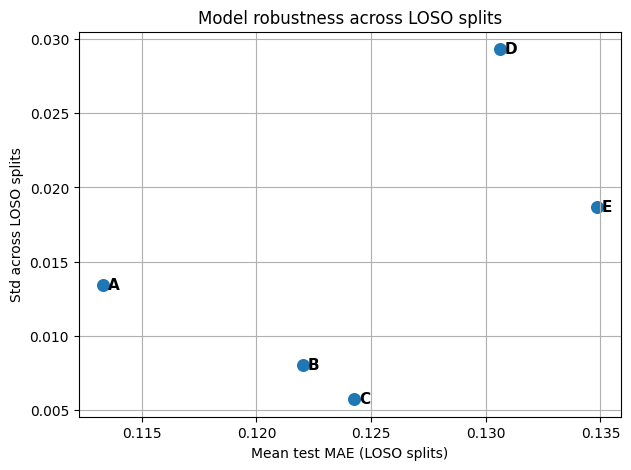

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    stability_df["mean_mae"],
    stability_df["std_across_sources"],
    s=70
)

# Annotate each point with its nickname
x_offset = (stability_df["mean_mae"].max() - stability_df["mean_mae"].min()) * 0.01

for _, row in stability_df.iterrows():
    plt.text(
        row["mean_mae"] + x_offset,
        row["std_across_sources"],
        row["model_tag"],
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="center"
    )

plt.xlabel("Mean test MAE (LOSO splits)")
plt.ylabel("Std across LOSO splits")
plt.title("Model robustness across LOSO splits")
plt.grid(True)

#### same as above ish - save to path

In [151]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display


png_path = FIG_DIR / "stability_scatter.png"

# 1) CREATE FIGURE
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    stability_df["mean_mae"],
    stability_df["std_across_sources"],
    s=80
)
# Annotate each point with its nickname
x_offset = (stability_df["mean_mae"].max() - stability_df["mean_mae"].min()) * 0.01

for _, row in stability_df.iterrows():
    plt.text(
        row["mean_mae"] + x_offset,
        row["std_across_sources"],
        row["model_tag"],
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="center"
    )


ax.set_xlabel("Mean test MAE")
ax.set_ylabel("Std across held-out sources")
ax.set_title("Model robustness across LOSO splits")
ax.grid(True)

# 2) SAVE FIGURE
fig.savefig(png_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved figure to:", png_path)
print("Exists:", png_path.exists())
print("File size (bytes):", png_path.stat().st_size)

Saved figure to: /margrethe/code/models/ViT_PROTOCOLS_reporting/reporting/figures/stability_scatter.png
Exists: True
File size (bytes): 56986


#### verify saved image

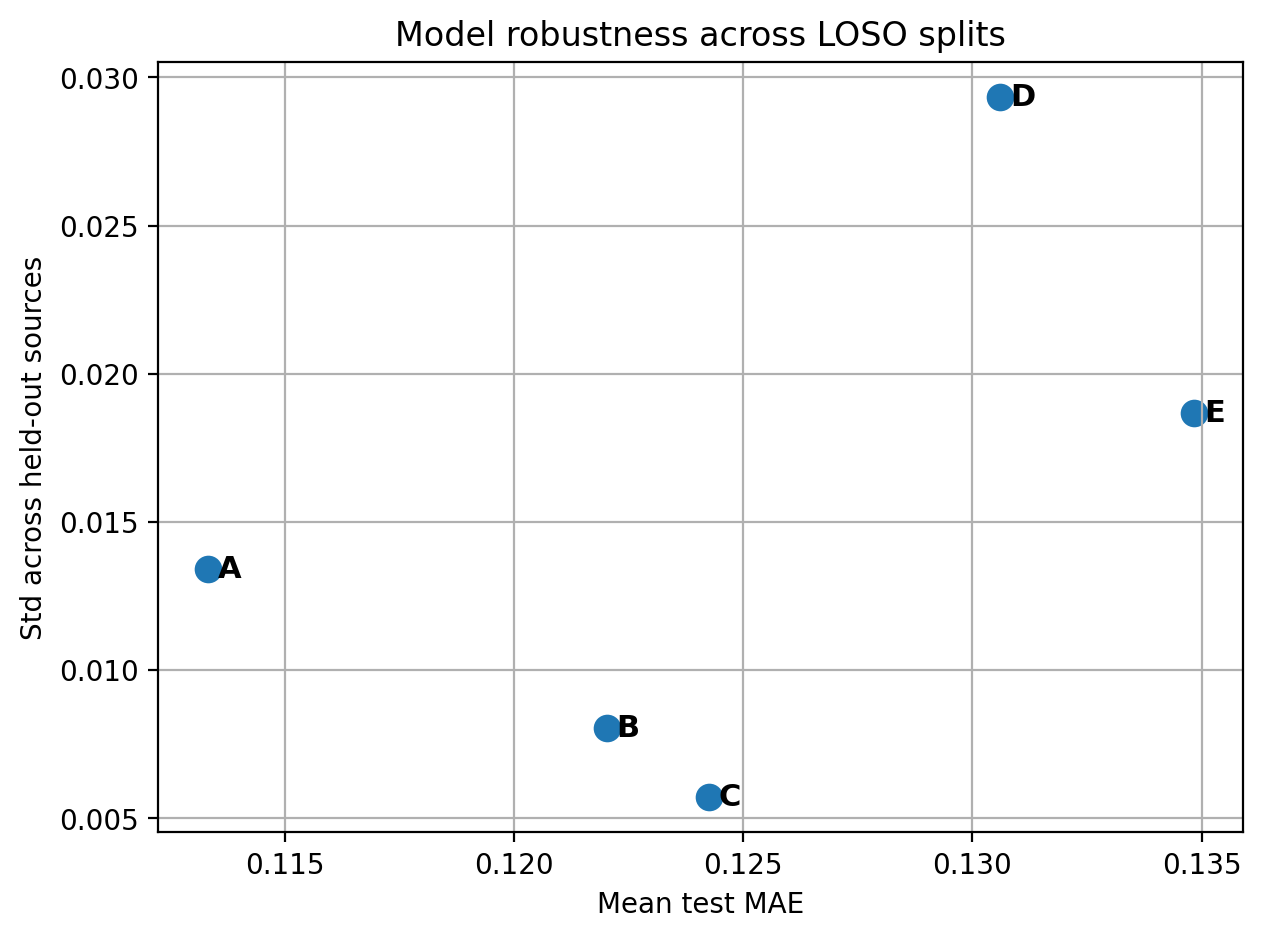

In [152]:

# FETCH + DISPLAY SAVED IMAGE (VERIFICATION)
img = Image.open(png_path)
display(img)